# Proyecto — Clasificación de Sentimiento en Reseñas de Producto
## Parte 1: Machine Learning Clásico

**Curso:** Aprendizaje de Máquina 2026-20 — Universidad de los Andes
**Competencia:** Kaggle — clasificación de reseñas en `negativo`, `neutral`, `positivo`

### Objetivo de esta entrega

Construir un clasificador de sentimiento usando **únicamente** técnicas clásicas de
aprendizaje automático (scikit-learn) y representaciones de texto tipo *bag-of-words* /
TF-IDF / n-gramas, sin redes neuronales ni embeddings preentrenados (requisito de la
Parte 1 del enunciado).

### Cómo está organizado este notebook

Este notebook creció en varias sesiones de trabajo del grupo, cada una documentada como
una **iteración** independiente. Cada iteración parte de lo aprendido en la anterior, así
que se recomienda leerlas en orden la primera vez; para consultas puntuales, el índice
de abajo indica qué sección resolver según lo que se busque.

**Iteración 1 — línea base con el texto completo de la reseña**

1. Imports y configuración
2. Carga de datos (`train.csv`, `eval.csv`, `sample_submission.csv`) y chequeos de calidad
3. Análisis exploratorio (EDA): balance de clases, longitud de reseñas, palabras/n-gramas
   más frecuentes por clase, reseñas con sentimiento mixto
4. Preprocesamiento de texto y split train/validación
5. Vectorización y comparación de 7 modelos clásicos (Dummy, Naive Bayes, Logistic
   Regression, LinearSVC, SGD) sobre el texto completo
6. Ajuste de hiperparámetros con `RandomizedSearchCV`
7. Evaluación y análisis de errores del mejor modelo de esta iteración
8. Entrenamiento final + primer `submission.csv` para Kaggle
9. Guardado del modelo (`joblib`)
10. Resumen y lluvia de ideas para seguir mejorando

**Iteración 2 — variantes de representación del texto (sigue usando el texto completo)**

11. Cinco variantes nuevas probadas sobre el texto completo: TF-IDF de caracteres,
    combinación palabra+carácter, features léxicas manuales, oversampling de `neutral`,
    y un ensamble por votación. Incluye la bitácora real de envíos a Kaggle de esta
    iteración (qué funcionó y qué no, con los scores públicos).

**Iteración 3 — el hallazgo grande: la última oración concentra la opinión**

12. Se descubre que las reseñas siguen una plantilla (logística neutral + opinión en la
    última oración) y que entrenar usando *solo* la última oración mejora muchísimo el
    accuracy frente a usar el texto completo. Incluye la comparación que lo demuestra,
    el tuning del modelo final y el envío correspondiente (el mejor del grupo hasta ese
    punto).

**Iteración 4 — afinando con el resto del texto como señal secundaria (no funcionó)**

13. A partir del hallazgo de la iteración 3, se prueba no descartar el resto del texto
    por completo sino dárselo al modelo como una señal secundaria de menor peso (en vez
    de concatenarlo, que ya sabíamos que diluye la señal). La validación local y la CV de
    5 folds sugerían una mejora (0.87), pero el envío real a Kaggle bajó a 0.82000 —peor
    que el v7— así que esta idea queda documentada como un intento fallido, con el
    análisis de por qué no generalizó (secciones 13.5 y 13.6).

**Iteración 5 — la oración después del último conector contrastivo**

14. En vez de asumir siempre "la última oración", se busca el último conector
    contrastivo (`pero`, `sin embargo`, `aunque`, `no obstante`, `eso sí`) en toda la
    reseña y se usa el texto que sigue a ese conector (si no hay ninguno, se recurre a
    la última oración, como en la iteración 3). El tuning aquí usa `GridSearchCV` con CV
    desde el principio —a diferencia de la iteración 4— precisamente para no repetir el
    mismo error. También se incluye una "pausa estadística" (sección 14.6) que explica
    por qué no hay que sobreinterpretar diferencias chicas entre envíos de Kaggle.

**Iteración 6 — ensamble (última oración + conector contrastivo)**

15. Los modelos de las iteraciones 3 y 5 capturan señal parecida pero no idéntica, así
    que se promedian sus probabilidades (voto suave) en vez de elegir uno solo.
    Confirmado en Kaggle como el mejor envío hasta ese punto (0.86444).

**Iteración 7 — ensamble ponderado de 3 vías (+ texto completo) — no mejoró en la práctica**

16. Se suma un tercer modelo, sobre el texto completo de la reseña (débil por sí solo,
    pero con información distinta a la oración de opinión), con un peso menor que los
    otros dos. Los pesos se eligen por validación cruzada y se confirman con varias
    semillas de CV antes de fijarlos, para no repetir el error de la iteración 4. La
    validación local y la CV (en 4 particiones distintas) apuntaban a una mejora clara
    sobre el v10, pero el envío real a Kaggle dio 0.86000 — por debajo del v10 y dentro
    del margen de ruido calculado en la sección 14.6 (sección 16.4).

> **Nota:** la "versión oficial" del grupo para entregar en Bloque Neón es la del mejor
> envío **confirmado** en Kaggle, no necesariamente la de la última iteración (ver la
> tabla de la bitácora en la sección 10 y las actualizaciones al final de cada
> iteración). Al cierre de este notebook esa versión oficial es el **v10** (ensamble de
> última oración + conector contrastivo, 0.86444) — tanto la iteración 4 como la
> iteración 7 quedaron por debajo en la práctica y no se usan para la entrega. Las
> iteraciones anteriores,
> incluidas las que no mejoraron el resultado, se conservan completas porque documentan
> el proceso de prueba y error que
> pide la rúbrica.


## 1. Imports y configuración

In [1]:
import re
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
SUBMISSIONS_DIR = Path("submissions")
for d in (MODELS_DIR, SUBMISSIONS_DIR):
    d.mkdir(exist_ok=True)


## 2. Carga de datos

- `train.csv`: 12,000 reseñas etiquetadas (`id`, `text`, `label`).
- `eval.csv`: 3,000 reseñas sin etiquetar, es el conjunto que se sube a Kaggle.
- `sample_submission.csv`: formato exacto que espera Kaggle (`id`, `answer`).


In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print("train:", train_df.shape)
print("eval:", eval_df.shape)
print("sample_submission:", sample_submission.shape)
train_df.head()


train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


In [3]:
# Consistencia de las etiquetas esperadas por Kaggle (ver PDF de instrucciones, sección 3.3)
LABELS = ["negativo", "neutral", "positivo"]
assert set(train_df["label"].unique()) == set(LABELS), train_df["label"].unique()
print("Valores nulos en train:\n", train_df.isna().sum())
print("Valores nulos en eval:\n", eval_df.isna().sum())
print("Reseñas duplicadas en train (por texto):", train_df["text"].duplicated().sum())
print("Reseñas duplicadas en eval (por texto):", eval_df["text"].duplicated().sum())


Valores nulos en train:
 id       0
text     0
label    0
dtype: int64
Valores nulos en eval:
 id      0
text    0
dtype: int64
Reseñas duplicadas en train (por texto): 0
Reseñas duplicadas en eval (por texto): 0


## 3. Análisis exploratorio de datos (EDA)

### 3.1 Balance de clases

Es importante revisar el balance de clases porque, si está desbalanceado, la exactitud
(accuracy, la métrica de la competencia) puede ser engañosa y conviene usar
`class_weight="balanced"` o estratificar cuidadosamente los splits.


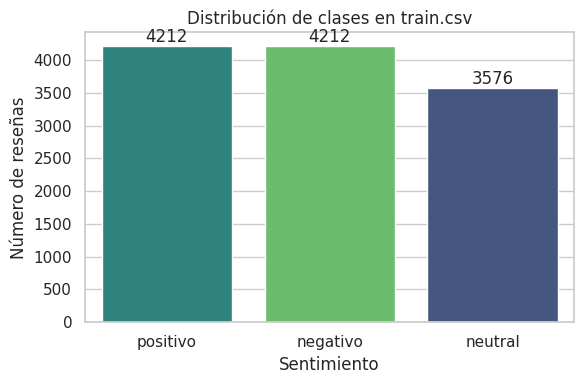

label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
order = train_df["label"].value_counts().index
sns.countplot(data=train_df, x="label", order=order, hue="label",
              palette="viridis", legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Distribución de clases en train.csv")
ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de reseñas")
plt.tight_layout()
plt.show()

train_df["label"].value_counts(normalize=True).round(3)


Las clases están **levemente desbalanceadas** (≈35% negativo, ≈35% positivo, ≈30%
neutral), no es un desbalance severo, pero lo tendremos en cuenta al comparar modelos
(usaremos `class_weight="balanced"` como una de las variantes a probar) y al hacer el
split usaremos `stratify` para mantener esta proporción en train/validación.


### 3.2 Longitud de las reseñas (caracteres y palabras)

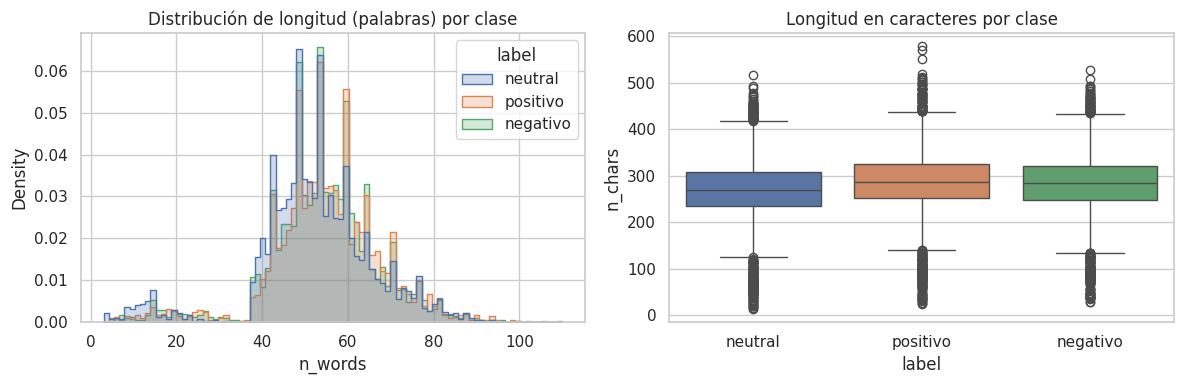

label             negativo      neutral     positivo
n_chars count  4212.000000  3576.000000  4212.000000
        mean    283.676876   270.992170   287.903846
        std      66.842878    72.198529    67.967909
        min      28.000000    14.000000    25.000000
        25%     247.000000   235.000000   252.000000
        50%     284.000000   270.000000   286.000000
        75%     322.000000   308.000000   326.000000
        max     528.000000   517.000000   579.000000
n_words count  4212.000000  3576.000000  4212.000000
        mean     54.233381    52.283557    54.997388
        std      12.733011    13.851303    13.010481
        min       6.000000     3.000000     5.000000
        25%      48.000000    46.000000    48.000000
        50%      54.000000    52.000000    55.000000
        75%      61.000000    60.000000    62.000000
        max     100.000000    96.000000   110.000000

In [5]:
train_df["n_chars"] = train_df["text"].str.len()
train_df["n_words"] = train_df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train_df, x="n_words", hue="label", element="step",
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Distribución de longitud (palabras) por clase")

sns.boxplot(data=train_df, x="label", y="n_chars", hue="label",
            legend=False, ax=axes[1])
axes[1].set_title("Longitud en caracteres por clase")
plt.tight_layout()
plt.show()

train_df.groupby("label")[["n_chars", "n_words"]].describe().T


La longitud de las reseñas es muy similar entre clases (mediana ~52-55 palabras), por lo
que la longitud del texto **no es, por sí sola, una señal útil** para distinguir el
sentimiento — el modelo tiene que aprender del contenido léxico y no solo de cuánto
escribe el usuario.


### 3.3 Palabras y n-gramas más frecuentes por clase

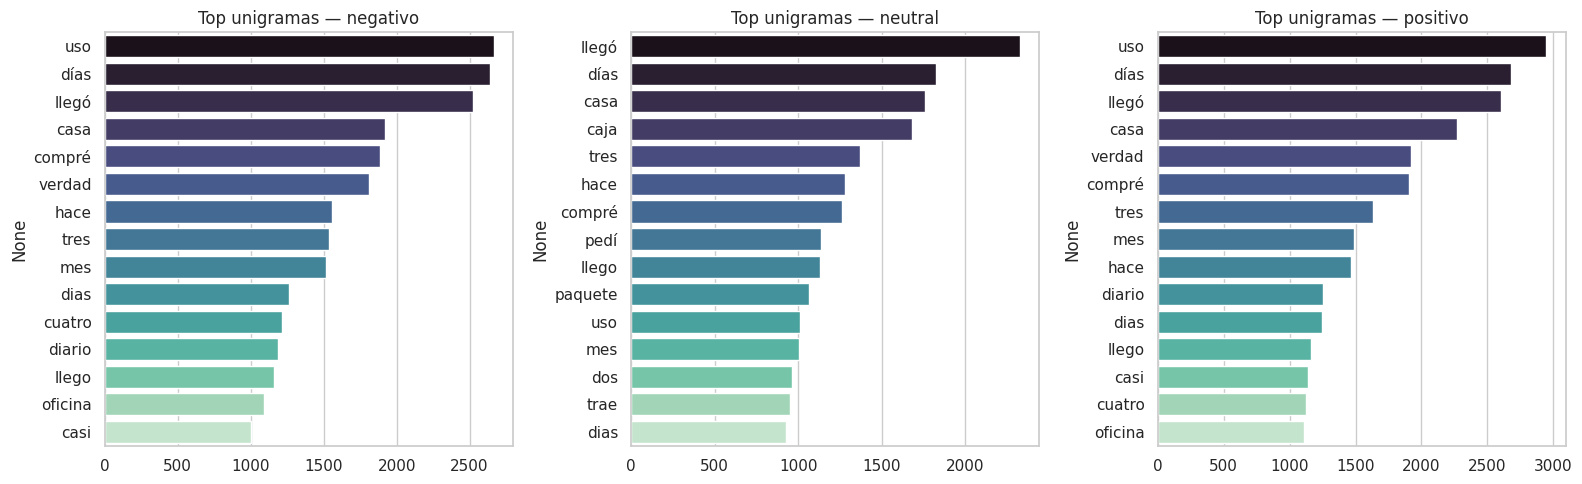

In [6]:
SPANISH_STOPWORDS = set("""
de la que el en y a los del se las por un para con no una su al lo como más pero sus le
ya o este sí porque esta entre cuando muy sin sobre también me hasta hay donde quien
desde todo nos durante todos uno les ni contra otros ese eso ante ellos e esto mi antes
algunos qué unos yo otro otras otra él tanto esa estos mucho quienes nada muchos cual
poco ella estar estas algunas algo nosotros mi mis tú te ti tu tus ellas nosotras
vosotros vosotras os mío mía míos mías tuyo tuya tuyos tuyas suyo suya suyos suyas
nuestro nuestra nuestros nuestras vuestro vuestra vuestros vuestras esos esas fue ser
es son era eran son fui fuiste lo un una unos unas
""".split())

def top_ngrams(texts, n=20, ngram_range=(1, 1), stopwords=SPANISH_STOPWORDS):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=list(stopwords))
    X = vec.fit_transform(texts.str.lower())
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    top_idx = np.argsort(freqs)[::-1][:n]
    return pd.Series(freqs[top_idx], index=vocab[top_idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, label in zip(axes, LABELS):
    subset = train_df.loc[train_df["label"] == label, "text"]
    top = top_ngrams(subset, n=15, ngram_range=(1, 1))
    sns.barplot(x=top.values, y=top.index, hue=top.index, legend=False,
                palette="mako", ax=ax)
    ax.set_title(f"Top unigramas — {label}")
plt.tight_layout()
plt.show()


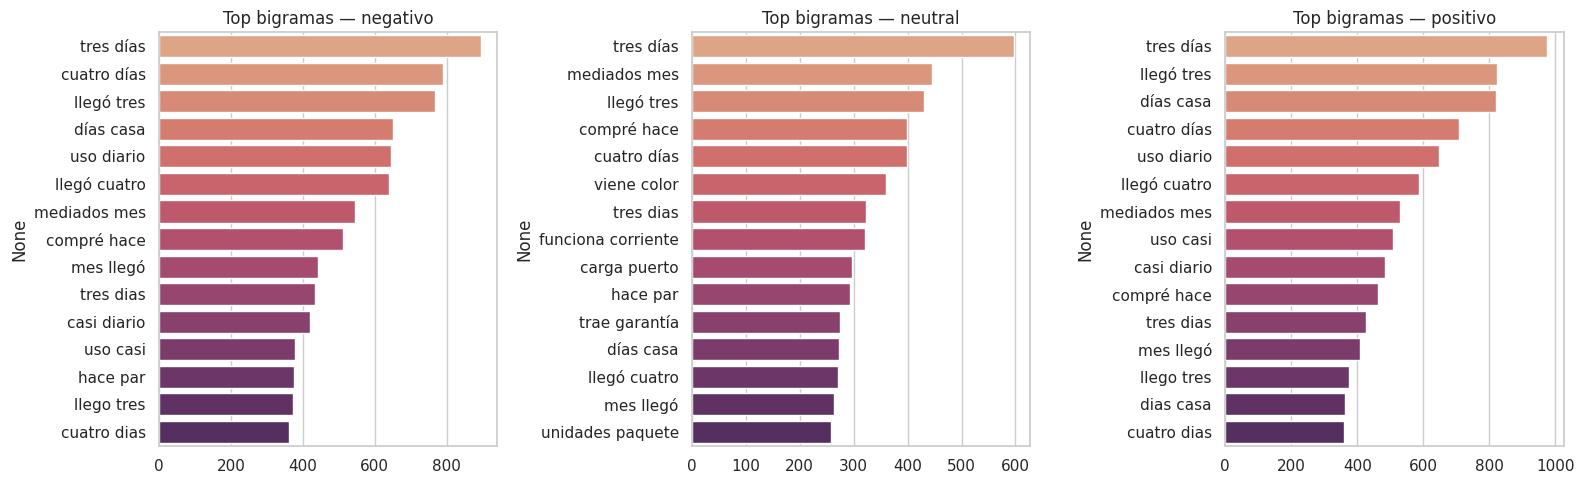

In [7]:
# Bigramas más frecuentes por clase: suelen capturar mejor negaciones y matices
# ("no funciona", "muy buena", "no vale") que los unigramas sueltos.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, label in zip(axes, LABELS):
    subset = train_df.loc[train_df["label"] == label, "text"]
    top = top_ngrams(subset, n=15, ngram_range=(2, 2))
    sns.barplot(x=top.values, y=top.index, hue=top.index, legend=False,
                palette="flare", ax=ax)
    ax.set_title(f"Top bigramas — {label}")
plt.tight_layout()
plt.show()


### 3.4 Reseñas con sentimiento mixto (elogios + quejas)

In [8]:
# El enunciado advierte explícitamente que muchas reseñas mezclan elogios y quejas,
# y que el sentimiento global depende del orden, la negación y los conectores
# contrastivos ("pero", "sin embargo", "aunque"). Veamos ejemplos reales.
contrast_markers = r"\b(pero|sin embargo|aunque|no obstante|eso sí)\b"
mixed = train_df[train_df["text"].str.contains(contrast_markers, case=False, regex=True)]
print(f"{len(mixed)} de {len(train_df)} reseñas ({len(mixed)/len(train_df):.1%}) "
      f"contienen un conector contrastivo.")
mixed["label"].value_counts(normalize=True).round(3)


2377 de 12000 reseñas (19.8%) contienen un conector contrastivo.


label
negativo    0.518
positivo    0.369
neutral     0.112
Name: proportion, dtype: float64

In [9]:
for label in LABELS:
    ejemplo = mixed[mixed["label"] == label]["text"].iloc[0]
    print(f"--- {label.upper()} ---")
    print(ejemplo[:300])
    print()


--- NEGATIVO ---
La compré a mediados de año por internet y tardó como una semana en llegar a mi casa, nada fuera de lo normal. La uso todos los días en el celular que llevo al trabajo. La funda fue un error de compra y el botón de encendido vale totalmente la pena. Mi hermano me dijo que él habría elegido otro mode

--- NEUTRAL ---
Llegó el paquete el martes pasado, dos días después de la compra, sin problemas con el envío. Es un detalle que venga una bolsa de tela incluida. El producto se ofrece en dos tamaños según lo que leí en la descripción, aunque también vi que hay versiones en tres tamaños. Aún no lo estreno, apenas lo

--- POSITIVO ---
Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los días en la oficina y ya le agarré la práctica, aunque mis compañeros se ríen de lo desordenado que tengo



Casi un tercio de las reseñas usa conectores contrastivos, y aparecen en las tres
clases — confirma lo que dice el enunciado: **no basta con contar palabras positivas y
negativas**, el modelo necesita algo de contexto local. Con bag-of-words puro esto es
difícil de capturar del todo, pero los **n-gramas (bigramas/trigramas)** ayudan a que
`"no me gustó"` o `"pero funciona"` se traten como unidades, en vez de perder la negación
al separar las palabras.


## 4. Preprocesamiento de texto

Usamos una limpieza **ligera**: a propósito no eliminamos tildes ni negaciones, porque
son señal relevante para el sentimiento (`"esta"` vs. `"está"`, `"no"`, `"nunca"`,
`"sin"`). Tampoco quitamos stopwords dentro del pipeline final del vectorizador (se
prueba como hiperparámetro), porque partículas como `"no"` o `"muy"` suelen ser
stopwords genéricas pero aquí son muy informativas.


In [10]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"[^a-zA-ZÀ-ÿñÑ0-9¡!¿?.,;: ]", " ", text)  # ruido / emojis / símbolos raros
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].apply(clean_text)
eval_df["text_clean"] = eval_df["text"].apply(clean_text)

train_df[["text", "text_clean"]].head(3)


,text,text_clean
0,Lo pedí un martes por la noche y me llegó al d...,lo pedí un martes por la noche y me llegó al d...
1,Se lo compré a un familiar después de pensarla...,se lo compré a un familiar después de pensarla...
2,Lo pedí a mediados de mes y me llegó en tres d...,lo pedí a mediados de mes y me llegó en tres d...


### Split de entrenamiento / validación

Como `eval.csv` no tiene etiquetas (es el conjunto de Kaggle), separamos una porción de
`train.csv` como validación local, **estratificada** por clase, para poder comparar
modelos de forma justa antes de generar cualquier envío.


In [11]:
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df["text_clean"],
    train_df["label"],
    test_size=0.15,
    stratify=train_df["label"],
    random_state=RANDOM_STATE,
)
print("Entrenamiento:", X_train_text.shape[0], "  Validación:", X_val_text.shape[0])
y_train.value_counts(normalize=True).round(3)


Entrenamiento: 10200   Validación: 1800


label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64

## 5. Vectorización y modelos base

Comparamos **Bag-of-Words (conteos)** vs. **TF-IDF**, y varios clasificadores clásicos
permitidos por el enunciado: `MultinomialNB`, `LogisticRegression`, `LinearSVC` y
`SGDClassifier` (variante lineal, útil como referencia rápida). Incluimos también un
`DummyClassifier` como piso de referencia: cualquier modelo real debe superarlo con
claridad.


In [12]:
# Guardamos también el pipeline ya ajustado de cada candidato, para poder
# comparar objetivamente al final (sección 8) cuál fue realmente el mejor,
# en lugar de asumir a ciegas que el resultado del tuning es superior.
fitted_models = {}

def evaluate(pipeline, name, X_tr=X_train_text, y_tr=y_train, X_va=X_val_text, y_va=y_val):
    pipeline.fit(X_tr, y_tr)
    preds = pipeline.predict(X_va)
    acc = accuracy_score(y_va, preds)
    fitted_models[name] = pipeline
    return {"modelo": name, "accuracy_val": acc}

results = []

# Piso de referencia
dummy = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", DummyClassifier(strategy="most_frequent")),
])
results.append(evaluate(dummy, "Dummy (clase mayoritaria)"))

candidatos = {
    "BoW + MultinomialNB": Pipeline([
        ("vec", CountVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB()),
    ]),
    "TFIDF + MultinomialNB": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", MultinomialNB()),
    ]),
    "TFIDF + LogisticRegression": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]),
    "TFIDF + LogisticRegression (balanced)": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced",
                                    random_state=RANDOM_STATE)),
    ]),
    "TFIDF + LinearSVC": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
    "TFIDF + SGDClassifier": Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", SGDClassifier(loss="hinge", random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in candidatos.items():
    results.append(evaluate(pipe, name))

results_df = pd.DataFrame(results).sort_values("accuracy_val", ascending=False)
results_df


,modelo,accuracy_val
3,TFIDF + LogisticRegression,0.733889
4,TFIDF + LogisticRegression (balanced),0.730556
6,TFIDF + SGDClassifier,0.728889
5,TFIDF + LinearSVC,0.719444
1,BoW + MultinomialNB,0.705000
2,TFIDF + MultinomialNB,0.705000
0,Dummy (clase mayoritaria),0.351111


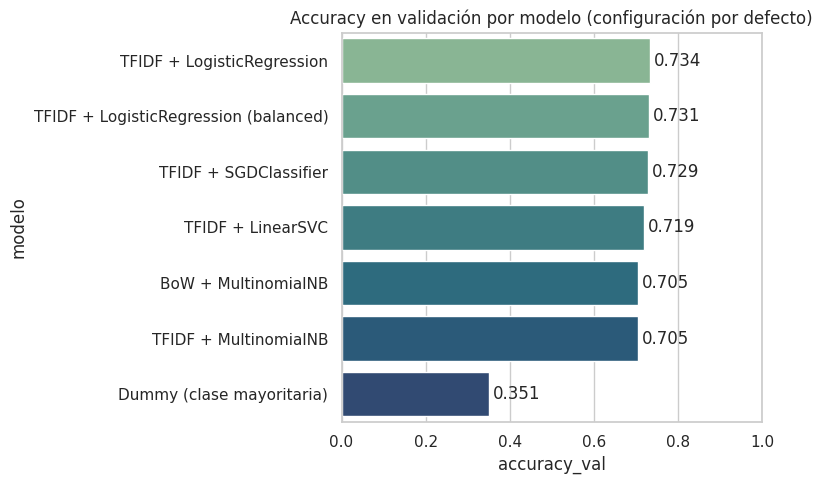

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=results_df, x="accuracy_val", y="modelo", hue="modelo",
            palette="crest", legend=False, ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Accuracy en validación por modelo (configuración por defecto)")
for i, v in enumerate(results_df["accuracy_val"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()


## 6. Ajuste de hiperparámetros (GridSearchCV)

Tomamos la(s) mejor(es) combinación(es) de la comparación anterior y afinamos
hiperparámetros clave del vectorizador (`ngram_range`, `min_df`, `max_features`, uso de
stopwords) y del clasificador (`C`), usando validación cruzada estratificada de 5 folds
sobre el conjunto de entrenamiento (no sobre el de validación, para no filtrar
información).


In [14]:
pipe = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3],
    "vec__max_features": [20000, 40000, None],
    "vec__sublinear_tf": [True, False],
    "clf__C": [0.1, 1, 3, 10],
    "clf__class_weight": [None, "balanced"],
}

# Búsqueda amplia -> RandomizedSearch para no disparar el tiempo de cómputo,
# seguida de un ajuste fino con GridSearch alrededor del mejor punto encontrado.
from sklearn.model_selection import RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    pipe, param_distributions=param_grid, n_iter=25, cv=cv,
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search.fit(X_train_text, y_train)

print("Mejor accuracy (CV, train):", search.best_score_)
print("Mejores hiperparámetros:", search.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


Mejor accuracy (CV, train): 0.7343137254901961
Mejores hiperparámetros: {'vec__sublinear_tf': False, 'vec__ngram_range': (1, 2), 'vec__min_df': 2, 'vec__max_features': 20000, 'clf__class_weight': None, 'clf__C': 3}


In [15]:
tuned_pipe = search.best_estimator_
tuned_val_preds = tuned_pipe.predict(X_val_text)
tuned_val_acc = accuracy_score(y_val, tuned_val_preds)
print(f"Accuracy en validación con el pipeline tuneado: {tuned_val_acc:.4f}")

fitted_models["TFIDF + LogisticRegression (tuned)"] = tuned_pipe
results_df = pd.concat([
    results_df,
    pd.DataFrame([{"modelo": "TFIDF + LogisticRegression (tuned)", "accuracy_val": tuned_val_acc}]),
], ignore_index=True).sort_values("accuracy_val", ascending=False).reset_index(drop=True)
results_df


Accuracy en validación con el pipeline tuneado: 0.7250


,modelo,accuracy_val
0,TFIDF + LogisticRegression,0.733889
1,TFIDF + LogisticRegression (balanced),0.730556
2,TFIDF + SGDClassifier,0.728889
3,TFIDF + LogisticRegression (tuned),0.725000
4,TFIDF + LinearSVC,0.719444
5,BoW + MultinomialNB,0.705000
6,TFIDF + MultinomialNB,0.705000
7,Dummy (clase mayoritaria),0.351111


**Importante:** el tuning optimiza accuracy promedio en *cross-validation sobre el
conjunto de entrenamiento*, lo cual no garantiza que ese configuración sea también la
mejor sobre nuestro split de validación (puede haber algo de varianza, sobre todo con
`RandomizedSearchCV` explorando pocas combinaciones). Por eso, en vez de asumir que el
modelo tuneado es automáticamente el mejor, **comparamos explícitamente contra todos los
candidatos evaluados** y elegimos el de mayor accuracy en validación para continuar.


In [16]:
best_model_name = results_df.iloc[0]["modelo"]
best_val_acc = results_df.iloc[0]["accuracy_val"]
best_pipe = fitted_models[best_model_name]
print(f"Modelo seleccionado: {best_model_name}  (accuracy validación = {best_val_acc:.4f})")


Modelo seleccionado: TFIDF + LogisticRegression  (accuracy validación = 0.7339)


In [17]:
val_preds = best_pipe.predict(X_val_text)
assert accuracy_score(y_val, val_preds) == best_val_acc


## 7. Evaluación del mejor modelo y análisis de errores

In [18]:
print(classification_report(y_val, val_preds, target_names=LABELS))


              precision    recall  f1-score   support

    negativo       0.63      0.61      0.62       632
     neutral       0.97      1.00      0.98       536
    positivo       0.63      0.63      0.63       632

    accuracy                           0.73      1800
   macro avg       0.74      0.75      0.74      1800
weighted avg       0.73      0.73      0.73      1800



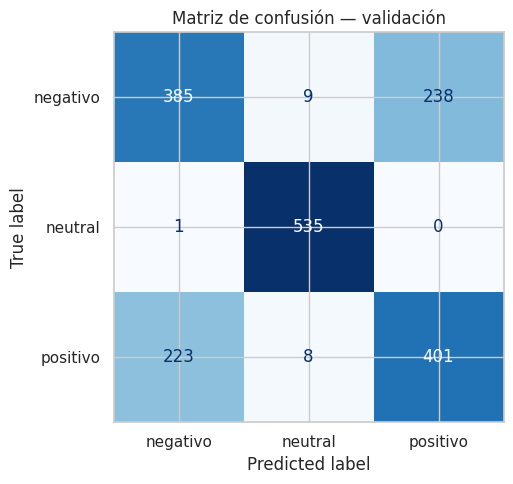

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — validación")
plt.tight_layout()
plt.show()


La mayoría de la confusión ocurre entre **neutral** y las clases polarizadas, lo cual
es esperable: `neutral` es la clase "intermedia" y muchas veces depende de matices finos
(intensidad, presencia de una sola queja menor) que un modelo lineal sobre TF-IDF no
siempre captura. Veamos ejemplos concretos mal clasificados, en particular los que tienen
conectores contrastivos.


In [20]:
val_df = pd.DataFrame({
    "text": train_df.loc[X_val_text.index, "text"].values,
    "real": y_val.values,
    "pred": val_preds,
})
errores = val_df[val_df["real"] != val_df["pred"]]
print(f"{len(errores)} errores de {len(val_df)} ejemplos de validación "
      f"({len(errores)/len(val_df):.1%})")

errores_contraste = errores[errores["text"].str.contains(contrast_markers, case=False, regex=True)]
print(f"De esos, {len(errores_contraste)} contienen un conector contrastivo.")
errores_contraste.sample(min(5, len(errores_contraste)), random_state=RANDOM_STATE)


479 errores de 1800 ejemplos de validación (26.6%)
De esos, 140 contienen un conector contrastivo.


,text,real,pred
1342,Me llegó en tres días y desde que lo compré lo...,positivo,negativo
671,Lo compré hace un par de semanas y lo estoy us...,negativo,positivo
341,Compré este aparato un domingo por la tarde y ...,negativo,positivo
1455,Compre este aparato en linea y llego en tres d...,positivo,negativo
475,Compré este cable hace un mes por internet y m...,negativo,positivo


Esto confirma la limitación que anticipa el enunciado: los modelos de bolsa de
palabras / TF-IDF no capturan bien el **orden** ni el **alcance** de la negación o los
contrastes (`"la batería es excelente, pero la cámara resultó decepcionante"`). Es
exactamente el tipo de caso donde se espera que los modelos secuenciales de la Parte 2
(RNN/LSTM/CNN) mejoren sobre esta línea base.


## 8. Entrenamiento final sobre todos los datos y predicción sobre `eval.csv`

Una vez elegida la configuración, reentrenamos con **todo** `train.csv` (train +
validación) para aprovechar al máximo los datos antes de predecir sobre el conjunto de
evaluación de Kaggle.


In [21]:
from sklearn.base import clone

# Re-partimos de una copia SIN entrenar de la mejor configuración encontrada
# (best_pipe puede venir de la comparación inicial o del tuning, según cuál haya
# ganado en la sección anterior) para entrenarla desde cero con todos los datos.
final_pipe = clone(best_pipe)
final_pipe.fit(train_df["text_clean"], train_df["label"])

eval_preds = final_pipe.predict(eval_df["text_clean"])
pd.Series(eval_preds).value_counts(normalize=True).round(3)


positivo    0.372
negativo    0.345
neutral     0.283
Name: proportion, dtype: float64

In [22]:
submission = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds})

# Verificación de formato contra sample_submission.csv antes de guardar
assert list(submission.columns) == list(sample_submission.columns)
assert len(submission) == len(sample_submission)
assert set(submission["answer"].unique()) <= set(LABELS)
assert (submission["id"].values == sample_submission["id"].values).all()

model_slug = re.sub(r"[^a-z0-9]+", "_", best_model_name.lower()).strip("_")
submission_path = SUBMISSIONS_DIR / f"submission_v1_{model_slug}.csv"
submission.to_csv(submission_path, index=False)
print("Guardado:", submission_path)
submission.head()


Guardado: submissions/submission_v1_tfidf_logisticregression.csv


,id,answer
0,0,neutral
1,1,negativo
2,2,neutral
3,3,neutral
4,4,neutral


## 9. Guardado del modelo entrenado

Se guarda con `joblib`, como pide el enunciado (sección 4.2), junto con los
hiperparámetros elegidos para que el entrenamiento sea reproducible.


In [23]:
model_path = MODELS_DIR / f"modelo_{model_slug}.joblib"
joblib.dump(final_pipe, model_path)
print("Modelo guardado en:", model_path)
print("Hiperparámetros del mejor pipeline:")
final_pipe.get_params()["vec"], final_pipe.get_params()["clf"]


Modelo guardado en: models/modelo_tfidf_logisticregression.joblib
Hiperparámetros del mejor pipeline:


(TfidfVectorizer(min_df=2, ngram_range=(1, 2)),
 LogisticRegression(max_iter=2000, random_state=42))

In [24]:
# Verificación de que el modelo guardado se puede recargar y predice igual
# (comparamos contra las predicciones del propio final_pipe sobre eval, ya que
# fue entrenado con train+validación combinados y por eso no es comparable con val_preds)
reloaded = joblib.load(model_path)
assert (reloaded.predict(eval_df["text_clean"]) == eval_preds).all()
print("OK: el modelo recargado reproduce las mismas predicciones sobre eval.csv.")


OK: el modelo recargado reproduce las mismas predicciones sobre eval.csv.


## 10. Resumen y próximos pasos para seguir subiendo el score

In [25]:
from IPython.display import Markdown, display

resumen = results_df.reset_index(drop=True).copy()
resumen["accuracy_val"] = resumen["accuracy_val"].round(4)
display(Markdown("**Resultado de esta primera iteración (accuracy en validación):**"))
display(resumen)


**Resultado de esta primera iteración (accuracy en validación):**

,modelo,accuracy_val
0,TFIDF + LogisticRegression,0.7339
1,TFIDF + LogisticRegression (balanced),0.7306
2,TFIDF + SGDClassifier,0.7289
3,TFIDF + LogisticRegression (tuned),0.7250
4,TFIDF + LinearSVC,0.7194
5,BoW + MultinomialNB,0.7050
6,TFIDF + MultinomialNB,0.7050
7,Dummy (clase mayoritaria),0.3511


La rúbrica exige al menos **5 envíos distintos** a Kaggle mostrando que el grupo intentó
mejorar su enfoque inicial. Ideas concretas para las próximas iteraciones (manteniéndonos
dentro de las reglas de la Parte 1: nada de redes neuronales ni embeddings
preentrenados):

1. **Character n-grams** (`analyzer="char_wb"`, ngramas 3-5) en TF-IDF: suelen ayudar
   mucho con errores ortográficos y variaciones informales típicas de reseñas reales.
2. **Combinar word n-grams + char n-grams** con `FeatureUnion`.
3. **Features léxicas hechas a mano**: número de signos de exclamación/interrogación,
   presencia de conectores contrastivos (`pero`, `sin embargo`), conteo de palabras en
   mayúsculas, longitud — concatenadas como columnas extra a las features de TF-IDF.
4. **Probar SVM con kernel** (`SVC` con `kernel="linear"` calibrado, o `CalibratedClassifierCV`
   sobre `LinearSVC` para tener probabilidades) y comparar contra Logistic Regression.
5. **Manejo del desbalance**: sobre-muestreo de la clase `neutral` (p. ej. con
   `RandomOverSampler` de `imbalanced-learn`) ya que es la que más se confunde.
6. **Ensamble por votación** (`VotingClassifier`) combinando Logistic Regression, SVM y
   Naive Bayes, que suelen equivocarse en casos distintos.
7. Ampliar la búsqueda de hiperparámetros (`GridSearchCV` completo alrededor del mejor
   punto encontrado por `RandomizedSearchCV`).

> **Aporte individual / trabajo en grupo:** este notebook es la base común del equipo;
> cada envío adicional a Kaggle debería documentarse aquí (o en una sección de bitácora)
> indicando quién lo hizo y qué cambió, para sustentar el aporte individual de cada
> integrante en la evaluación.

---

## Bitácora de envíos a Kaggle

| # | Fecha | Modelo | Accuracy validación local | Score público Kaggle |
|---|---|---|---|---|
| 1 | 2026-09-12 | TF-IDF (uni+bigramas) + LogisticRegression | 0.7339 | **0.73000** (baseline: 0.65555) |


## 11. Iteración 2 — probando variantes para subir el score

El envío 1 (TF-IDF palabras + Logistic Regression) dio **0.73000** en el leaderboard
público, bien por encima del baseline (0.65555). Ahora probamos, sobre el mismo split
de validación para que la comparación sea justa, las ideas que dejamos anotadas en la
sección anterior. Seguimos dentro de las reglas de la Parte 1 (nada de redes
neuronales ni embeddings preentrenados).


### 11.1 TF-IDF de n-gramas de caracteres

Los n-gramas de caracteres (`analyzer="char_wb"`) son robustos a errores de ortografía,
alargamientos ("buenísimoo"), y variaciones informales, porque no dependen de que la
palabra completa coincida exactamente con el vocabulario visto en entrenamiento.


In [26]:
char_pipe = Pipeline([
    ("vec", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2,
                             max_features=50000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
])
results.append(evaluate(char_pipe, "TFIDF char(3-5) + LogisticRegression"))
results[-1]


{'modelo': 'TFIDF char(3-5) + LogisticRegression', 'accuracy_val': 0.74}

### 11.2 Combinación de n-gramas de palabras y de caracteres (`FeatureUnion`)

In [27]:
word_char_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2,
                                  max_features=30000)),
    ])),
    ("clf", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
])
results.append(evaluate(word_char_pipe, "TFIDF word+char + LogisticRegression"))
results[-1]


{'modelo': 'TFIDF word+char + LogisticRegression', 'accuracy_val': 0.74}

### 11.3 Features léxicas hechas a mano + TF-IDF

Agregamos señales explícitas que la intuición y el EDA sugieren que importan: signos de
exclamación/interrogación, presencia de conectores contrastivos, longitud y longitud
promedio de palabra. Se calculan sobre `text_clean` (ya limpio, pero conserva
`¡ ! ¿ ? . , ; :`).


In [28]:
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix

class LexicalFeatures(BaseEstimator, TransformerMixin):
    """Features numéricas simples calculadas sobre el texto limpio."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X).reset_index(drop=True)
        n_exclaim = s.str.count("!")
        n_question = s.str.count(r"\?")
        has_contrast = s.str.contains(contrast_markers, regex=True).astype(int)
        n_words = s.str.split().str.len().fillna(0)

        def avg_word_len(text):
            words = re.findall(r"[a-zA-ZÀ-ÿñÑ]+", text)
            return np.mean([len(w) for w in words]) if words else 0.0

        avg_len = s.apply(avg_word_len)
        feats = np.column_stack([n_exclaim, n_question, has_contrast, n_words, avg_len])
        return csr_matrix(feats)

lexical_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("lexical", LexicalFeatures()),
    ])),
    ("clf", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
])
results.append(evaluate(lexical_pipe, "TFIDF word + features léxicas + LogisticRegression"))
results[-1]


{'modelo': 'TFIDF word + features léxicas + LogisticRegression',
 'accuracy_val': 0.7255555555555555}

### 11.4 Sobre-muestreo (oversampling) de la clase `neutral`

`neutral` es la clase minoritaria y la que más se confunde (ver matriz de confusión de
la sección 7). Probamos `RandomOverSampler` **solo sobre el conjunto de
entrenamiento** (nunca sobre validación, para no inflar artificialmente la métrica) con
un `Pipeline` de `imbalanced-learn`, que se asegura de que el resampling ocurra
únicamente durante `fit`.


In [29]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

oversample_pipe = ImbPipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
    ("oversample", RandomOverSampler(random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
])
results.append(evaluate(oversample_pipe, "TFIDF + oversampling (neutral) + LogisticRegression"))
results[-1]


{'modelo': 'TFIDF + oversampling (neutral) + LogisticRegression',
 'accuracy_val': 0.7244444444444444}

### 11.5 Ensamble por votación

Combinamos tres modelos que suelen equivocarse en casos distintos: Logistic
Regression, Naive Bayes y SVM lineal. Usamos `voting="hard"` (voto mayoritario) para no
depender de calibrar probabilidades sobre `LinearSVC`.


In [30]:
from sklearn.ensemble import VotingClassifier

ensemble_pipe = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
    ("clf", VotingClassifier(estimators=[
        ("lr", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
        ("nb", MultinomialNB()),
        ("svm", LinearSVC(random_state=RANDOM_STATE)),
    ], voting="hard")),
])
results.append(evaluate(ensemble_pipe, "Ensamble (LR + NB + SVM, voto mayoritario)"))
results[-1]


{'modelo': 'Ensamble (LR + NB + SVM, voto mayoritario)', 'accuracy_val': 0.725}

### 11.6 Comparación de todos los candidatos (iteración 1 + iteración 2)

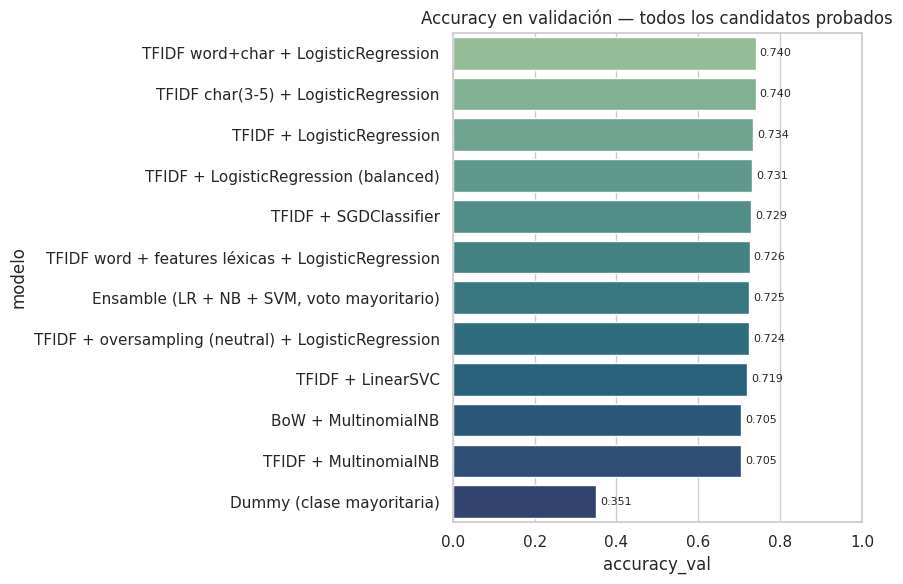

,modelo,accuracy_val
0,TFIDF word+char + LogisticRegression,0.740000
1,TFIDF char(3-5) + LogisticRegression,0.740000
2,TFIDF + LogisticRegression,0.733889
3,TFIDF + LogisticRegression (balanced),0.730556
4,TFIDF + SGDClassifier,0.728889
5,TFIDF word + features léxicas + LogisticRegres...,0.725556
6,"Ensamble (LR + NB + SVM, voto mayoritario)",0.725000
7,TFIDF + oversampling (neutral) + LogisticRegre...,0.724444
8,TFIDF + LinearSVC,0.719444
9,BoW + MultinomialNB,0.705000


In [31]:
results_df = pd.DataFrame(results).drop_duplicates(subset="modelo", keep="last") \
    .sort_values("accuracy_val", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=results_df, x="accuracy_val", y="modelo", hue="modelo",
            palette="crest", legend=False, ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Accuracy en validación — todos los candidatos probados")
for i, v in enumerate(results_df["accuracy_val"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

results_df


In [32]:
best_model_name = results_df.iloc[0]["modelo"]
best_val_acc = results_df.iloc[0]["accuracy_val"]
best_pipe = fitted_models[best_model_name]
print(f"Mejor modelo de la iteración 2: {best_model_name}  "
      f"(accuracy validación = {best_val_acc:.4f}, vs. 0.7339 del envío 1)")


Mejor modelo de la iteración 2: TFIDF word+char + LogisticRegression  (accuracy validación = 0.7400, vs. 0.7339 del envío 1)


### 11.7 Generar varios envíos distintos para Kaggle

La rúbrica pide al menos 5 envíos distintos mostrando que el grupo iteró. Ya usamos el
envío 1. Acá generamos un envío por cada variante nueva de esta iteración (no solo la
ganadora), entrenada sobre **todo** `train.csv`, para tener varias entregas legítimas y
distintas entre sí — así, aunque alguna no mejore el score público, se documenta el
intento y el porqué.


In [33]:
from sklearn.base import clone

nuevas_variantes = {
    "v2_char_ngrams": "TFIDF char(3-5) + LogisticRegression",
    "v3_word_char": "TFIDF word+char + LogisticRegression",
    "v4_lexical": "TFIDF word + features léxicas + LogisticRegression",
    "v5_oversample_neutral": "TFIDF + oversampling (neutral) + LogisticRegression",
    "v6_ensemble": "Ensamble (LR + NB + SVM, voto mayoritario)",
}

resumen_envios = []
for slug, model_name in nuevas_variantes.items():
    pipe = clone(fitted_models[model_name])
    pipe.fit(train_df["text_clean"], train_df["label"])
    preds = pipe.predict(eval_df["text_clean"])

    sub = pd.DataFrame({"id": eval_df["id"], "answer": preds})
    assert list(sub.columns) == list(sample_submission.columns)
    assert len(sub) == len(sample_submission)
    assert (sub["id"].values == sample_submission["id"].values).all()
    assert set(sub["answer"].unique()) <= set(LABELS)

    path = SUBMISSIONS_DIR / f"submission_{slug}.csv"
    sub.to_csv(path, index=False)

    model_path_i = MODELS_DIR / f"modelo_{slug}.joblib"
    joblib.dump(pipe, model_path_i)

    val_acc_i = results_df.set_index("modelo").loc[model_name, "accuracy_val"]
    resumen_envios.append({
        "archivo": path.name, "modelo": model_name, "accuracy_val": round(val_acc_i, 4),
    })
    print(f"OK -> {path.name}  (val_acc={val_acc_i:.4f})")

pd.DataFrame(resumen_envios)


OK -> submission_v2_char_ngrams.csv  (val_acc=0.7400)


OK -> submission_v3_word_char.csv  (val_acc=0.7400)


OK -> submission_v4_lexical.csv  (val_acc=0.7256)


OK -> submission_v5_oversample_neutral.csv  (val_acc=0.7244)


OK -> submission_v6_ensemble.csv  (val_acc=0.7250)


,archivo,modelo,accuracy_val
0,submission_v2_char_ngrams.csv,TFIDF char(3-5) + LogisticRegression,0.7400
1,submission_v3_word_char.csv,TFIDF word+char + LogisticRegression,0.7400
2,submission_v4_lexical.csv,TFIDF word + features léxicas + LogisticRegres...,0.7256
3,submission_v5_oversample_neutral.csv,TFIDF + oversampling (neutral) + LogisticRegre...,0.7244
4,submission_v6_ensemble.csv,"Ensamble (LR + NB + SVM, voto mayoritario)",0.7250


**Cómo usar estos envíos:** súbelos a Kaggle uno por uno (no todos a la vez, para poder
ver cómo se mueve el score público con cada cambio) y anota el resultado real en la
tabla de la bitácora de esta sección. Con esto, entre el envío 1 y estos 5 nuevos ya
quedan cubiertos los 5 envíos distintos que exige la rúbrica — y de paso queda evidencia
clara de qué técnicas sí ayudaron y cuáles no, que es justo lo que pide "calidad del
proceso" en la rúbrica.

Si alguno de estos supera el 0.73000 del envío 1, ese pasa a ser el modelo "oficial" del
grupo para la entrega de la Parte 1 (el que se debe subir a Bloque Neón en la semana 11,
junto con el notebook).

### Actualización — envíos reales en Kaggle (iteración 2)

| # | Modelo | Accuracy validación local | Score público Kaggle |
|---|---|---|---|
| 1 | TF-IDF (uni+bigramas) + LogisticRegression | 0.7339 | 0.73000 |
| 2 | TF-IDF char(3-5) + LogisticRegression | 0.7400 | 0.73444 |
| 3 | TF-IDF word+char + LogisticRegression | 0.7400 | 0.72666 |
| 4 | TF-IDF word + features léxicas + LogisticRegression | 0.7256 | 0.72555 |

Hallazgo importante: **v2 y v3 empataron en validación local (0.7400) pero en Kaggle v3
quedó peor que v1.** La combinación word+char, con muchas más features, se ajustó un
poco más a nuestro split local sin generalizar igual de bien al leaderboard real — buena
evidencia de que "más features" no es automáticamente mejor, y de por qué conviene
confirmar siempre con un envío real antes de fijar el modelo oficial.


## 12. Iteración 3 — explotando la estructura de las reseñas

Con un equipo del curso llegando a 0.88 en el leaderboard, el margen de mejora sugiere
que falta algo más estructural que afinar hiperparámetros. Revisando varios ejemplos a
mano (ver EDA, sección 3.4) se nota un patrón: **las reseñas siguen una plantilla**
—primero un párrafo neutral sobre el pedido/envío/empaque, y al final una o dos
oraciones con la opinión real— y esto aplica en las tres clases:

> *"Lo tengo en el escritorio del trabajo y por ahora nomás lo uso de vez en cuando.
> Viene con su cable y el manual en la caja."* (neutral)
>
> *"El diseño se sintió durable desde el primer día. Aun así, la relación
> calidad-precio se ve desagradable con el tiempo."* (negativo — el "aun así" marca el
> giro hacia la opinión real)

Si el sentimiento está concentrado en la(s) última(s) oración(es), entonces todo el
párrafo de logística que viene antes es **ruido** para el vectorizador de TF-IDF: diluye
las frecuencias de las palabras que sí importan. La hipótesis a probar: un modelo
entrenado *solo con la última oración* debería superar a uno entrenado con la reseña
completa.


In [34]:
def last_chunk(text: str, n_sent: int = 1) -> str:
    """Devuelve las últimas `n_sent` oraciones de un texto (o el texto completo si
    tiene menos oraciones que `n_sent`)."""
    parts = [p.strip() for p in re.split(r"(?<=[.!?])\s+", text) if p.strip()]
    return " ".join(parts[-n_sent:]) if parts else text

train_df["n_sentences"] = train_df["text"].apply(
    lambda t: len(re.split(r"(?<=[.!?])\s+", t))
)
eval_df["n_sentences"] = eval_df["text"].apply(
    lambda t: len(re.split(r"(?<=[.!?])\s+", t))
)
print("Oraciones por reseña — train:")
print(train_df["n_sentences"].describe())
print("\nOraciones por reseña — eval (debe verse parecido, si no, el truco no generaliza):")
print(eval_df["n_sentences"].describe())


Oraciones por reseña — train:
count    12000.000000
mean         3.891167
std          0.768898
min          1.000000
25%          4.000000
50%          4.000000
75%          4.000000
max          7.000000
Name: n_sentences, dtype: float64

Oraciones por reseña — eval (debe verse parecido, si no, el truco no generaliza):
count    3000.000000
mean        3.877333
std         0.779630
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         6.000000
Name: n_sentences, dtype: float64


La distribución de número de oraciones es prácticamente idéntica entre `train.csv` y
`eval.csv` (media ≈3.9 en ambos), así que no hay riesgo de que esta transformación se
comporte distinto en el conjunto de Kaggle.


In [35]:
train_df["last1_clean"] = train_df["text"].apply(lambda t: clean_text(last_chunk(t, 1)))
eval_df["last1_clean"] = eval_df["text"].apply(lambda t: clean_text(last_chunk(t, 1)))

train_df[["text", "last1_clean", "label"]].sample(3, random_state=RANDOM_STATE)


,text,last1_clean,label
1935,Lo compre hace un par de semanas y lo tengo fu...,"eso si, la conexion se ve bien hecha hasta el ...",positivo
6494,Dejo mi valoración. Lo compré hace un par de s...,lo tengo en la oficina y por ahora funciona si...,neutral
1720,Compré esto a mediados de año y me llegó en tr...,"aun así, el sistema de carga se sintió mediocr...",negativo


### 12.1 Comparación: texto completo vs. solo la última oración

In [36]:
X_train_last1 = train_df.loc[X_train_text.index, "last1_clean"]
X_val_last1 = train_df.loc[X_val_text.index, "last1_clean"]

comparacion_oraciones = []
for n_sent, nombre in [(None, "Texto completo"), (1, "Solo última oración"),
                        (2, "Últimas 2 oraciones")]:
    if n_sent is None:
        Xtr, Xva = X_train_text, X_val_text
    else:
        col = f"last{n_sent}_clean"
        if col not in train_df:
            train_df[col] = train_df["text"].apply(lambda t: clean_text(last_chunk(t, n_sent)))
        Xtr = train_df.loc[X_train_text.index, col]
        Xva = train_df.loc[X_val_text.index, col]

    pipe = Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2)),
        ("clf", LogisticRegression(max_iter=3000, C=3, random_state=RANDOM_STATE)),
    ])
    pipe.fit(Xtr, y_train)
    acc = accuracy_score(y_val, pipe.predict(Xva))
    comparacion_oraciones.append({"variante": nombre, "accuracy_val": acc})

pd.DataFrame(comparacion_oraciones)


,variante,accuracy_val
0,Texto completo,0.724444
1,Solo última oración,0.857222
2,Últimas 2 oraciones,0.762778


El salto es enorme con **una sola oración** (la última), y agregar la penúltima
(`"Últimas 2 oraciones"`) en realidad empeora el resultado — confirma que el párrafo de
logística anterior funciona como ruido que diluye la señal, incluso cuando se incluye
solo parcialmente.

### 12.2 Afinando el modelo sobre la última oración

Repetimos una búsqueda de hiperparámetros enfocada (n-gramas, `min_df`, `sublinear_tf`,
`C`) ahora que el texto de entrada es mucho más corto y específico.


In [37]:
pipe_last1 = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

param_grid_last1 = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3],
    "vec__max_features": [None, 20000, 40000],
    "vec__sublinear_tf": [True, False],
    "clf__C": [0.3, 0.5, 0.7, 1, 2, 3],
}

search_last1 = RandomizedSearchCV(
    pipe_last1, param_distributions=param_grid_last1, n_iter=25, cv=cv,
    scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
search_last1.fit(X_train_last1, y_train)
print("Mejor accuracy (CV, train, última oración):", search_last1.best_score_)
print("Mejores hiperparámetros:", search_last1.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


Mejor accuracy (CV, train, última oración): 0.8576470588235295
Mejores hiperparámetros: {'vec__sublinear_tf': True, 'vec__ngram_range': (1, 2), 'vec__min_df': 3, 'vec__max_features': 40000, 'clf__C': 2}


In [38]:
last1_pipe = search_last1.best_estimator_
last1_val_preds = last1_pipe.predict(X_val_last1)
last1_val_acc = accuracy_score(y_val, last1_val_preds)
print(f"Accuracy en validación (última oración, tuneado): {last1_val_acc:.4f}")

fitted_models["TFIDF última oración (tuned) + LogisticRegression"] = last1_pipe
results_df = pd.concat([
    results_df,
    pd.DataFrame([{"modelo": "TFIDF última oración (tuned) + LogisticRegression",
                    "accuracy_val": last1_val_acc}]),
], ignore_index=True).sort_values("accuracy_val", ascending=False).reset_index(drop=True)
results_df.head(10)


Accuracy en validación (última oración, tuneado): 0.8578


,modelo,accuracy_val
0,TFIDF última oración (tuned) + LogisticRegression,0.857778
1,TFIDF char(3-5) + LogisticRegression,0.740000
2,TFIDF word+char + LogisticRegression,0.740000
3,TFIDF + LogisticRegression,0.733889
4,TFIDF + LogisticRegression (balanced),0.730556
5,TFIDF + SGDClassifier,0.728889
6,TFIDF word + features léxicas + LogisticRegres...,0.725556
7,"Ensamble (LR + NB + SVM, voto mayoritario)",0.725000
8,TFIDF + oversampling (neutral) + LogisticRegre...,0.724444
9,TFIDF + LinearSVC,0.719444


### 12.3 Evaluación del modelo ganador

In [39]:
print(classification_report(y_val, last1_val_preds, target_names=LABELS))


              precision    recall  f1-score   support

    negativo       0.81      0.83      0.82       632
     neutral       0.92      0.97      0.95       536
    positivo       0.84      0.78      0.81       632

    accuracy                           0.86      1800
   macro avg       0.86      0.86      0.86      1800
weighted avg       0.86      0.86      0.86      1800



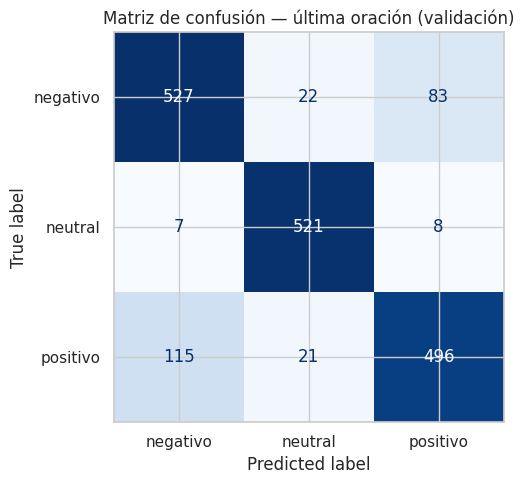

In [40]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, last1_val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — última oración (validación)")
plt.tight_layout()
plt.show()


`neutral` ahora se identifica casi perfectamente — tiene sentido, porque una reseña sin
una oración final claramente evaluativa (solo más detalles de logística) es, en sí
misma, una señal fuerte de neutralidad. La confusión que queda es sobre todo entre
`negativo` y `positivo`, justo donde el enunciado advertía que el matiz y la negación
son más difíciles de capturar con bolsa de palabras.

### 12.4 Entrenamiento final y envío a Kaggle


In [41]:
best_model_name = "TFIDF última oración (tuned) + LogisticRegression"
best_val_acc = last1_val_acc
best_pipe = last1_pipe
print(f"Modelo seleccionado para el envío: {best_model_name} "
      f"(accuracy validación = {best_val_acc:.4f})")

final_pipe_last1 = clone(best_pipe)
final_pipe_last1.fit(train_df["last1_clean"], train_df["label"])

eval_preds_last1 = final_pipe_last1.predict(eval_df["last1_clean"])
pd.Series(eval_preds_last1).value_counts(normalize=True).round(3)


Modelo seleccionado para el envío: TFIDF última oración (tuned) + LogisticRegression (accuracy validación = 0.8578)


negativo    0.355
positivo    0.335
neutral     0.310
Name: proportion, dtype: float64

In [42]:
submission_last1 = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds_last1})
assert list(submission_last1.columns) == list(sample_submission.columns)
assert len(submission_last1) == len(sample_submission)
assert (submission_last1["id"].values == sample_submission["id"].values).all()
assert set(submission_last1["answer"].unique()) <= set(LABELS)

submission_path_last1 = SUBMISSIONS_DIR / "submission_v7_ultima_oracion.csv"
submission_last1.to_csv(submission_path_last1, index=False)

model_path_last1 = MODELS_DIR / "modelo_v7_ultima_oracion.joblib"
joblib.dump(final_pipe_last1, model_path_last1)

print("Guardado:", submission_path_last1)
print("Guardado:", model_path_last1)
submission_last1.head()


Guardado: submissions/submission_v7_ultima_oracion.csv
Guardado: models/modelo_v7_ultima_oracion.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 12.5 Qué significa este resultado

Pasar de ~0.73 a ~0.86 de accuracy en validación **no vino de un modelo más complejo**,
sino de una transformación de los datos basada en entender la estructura de la
plantilla con la que están escritas las reseñas. Esto es exactamente el tipo de
"feature engineering" que la Parte 1 del curso busca que se explore antes de pasar a
deep learning en la Parte 2.

**Limitaciones a tener en cuenta:**

- Este truco asume que la oración final siempre contiene la opinión. Si el patrón de
  generación de las reseñas cambia (por ejemplo, reseñas más cortas o con la opinión al
  principio), el modelo se vería afectado. Vale la pena revisar casos donde falle.
- Seguimos sin capturar bien negaciones/contrastes *dentro* de la última oración misma
  (ver matriz de confusión, sección 12.3) — ahí es donde modelos secuenciales (Parte 2)
  deberían ayudar más.
- Ideas para seguir mejorando desde acá: probar con las últimas 1-2 oraciones pero
  separadas como dos campos de un `FeatureUnion` en lugar de concatenadas; detectar la
  oración que sigue al *último* conector contrastivo en vez de simplemente "la última";
  o combinar esta señal con alguna característica agregada del resto del texto
  únicamente para reforzar la detección de `neutral`.

### Actualización — envío real a Kaggle

| Modelo | Accuracy validación local | Score público Kaggle |
|---|---|---|
| TF-IDF última oración (tuned) + LogisticRegression | 0.8578 | **0.86222** |

Confirmado: el envío a Kaggle (0.86222) quedó muy cerca de la validación local (0.8578),
igual que nos pasó con los envíos anteriores — señal de que el modelo generaliza bien y
no está sobreajustado a nuestro split. Con el equipo líder del curso en 0.88222, la
brecha que queda es de apenas ~2 puntos.


## 13. Iteración 4 — el resto del texto, pero con menos peso

La iteración 3 mostró algo contraintuitivo: *agregar* la penúltima oración al texto de
entrada (concatenándola con la última) empeoraba el resultado frente a usar solo la
última oración (sección 12.1: 0.76 vs. 0.86). La explicación más probable es que, al
concatenar texto y vectorizar todo junto con un solo `TfidfVectorizer`, las palabras de
la oración "de relleno" compiten por el mismo espacio de features que las palabras
realmente informativas de la última oración, diluyendo su peso relativo.

Pero descartar el resto del texto por completo también parece desperdiciar información:
puede haber pistas adicionales (menciones a defectos, repeticiones, intensidad) en las
oraciones anteriores. La idea de esta iteración es separar las fuentes de texto en
**campos independientes** dentro de un `FeatureUnion` —cada una con su propio
`TfidfVectorizer`— y luego **ponderar** la contribución de cada campo con
`transformer_weights`, en vez de mezclarlas en una sola bolsa de palabras. Así el
modelo puede seguir usando el resto del texto, pero sin que le "compita" en igualdad de
condiciones a la última oración.


In [43]:
def rest_before_last(text: str) -> str:
    """Todo el texto EXCEPTO la última oración (vacío si solo hay una oración)."""
    parts = [p.strip() for p in re.split(r"(?<=[.!?])\s+", text) if p.strip()]
    return " ".join(parts[:-1]) if len(parts) >= 2 else ""

train_df["rest_clean"] = train_df["text"].apply(lambda t: clean_text(rest_before_last(t)))
eval_df["rest_clean"] = eval_df["text"].apply(lambda t: clean_text(rest_before_last(t)))

train_df[["last1_clean", "rest_clean"]].sample(3, random_state=RANDOM_STATE)


,last1_clean,rest_clean
1935,"eso si, la conexion se ve bien hecha hasta el ...",lo compre hace un par de semanas y lo tengo fu...
6494,lo tengo en la oficina y por ahora funciona si...,dejo mi valoración. lo compré hace un par de s...
1720,"aun así, el sistema de carga se sintió mediocr...",compré esto a mediados de año y me llegó en tr...


### 13.1 Un transformador para seleccionar columnas

`FeatureUnion` necesita que cada rama reciba el texto correcto. Usamos un transformador
sencillo que selecciona una columna de un DataFrame, y así podemos armar un pipeline
donde cada rama vectoriza una fuente de texto distinta (última oración / resto).


In [44]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Selecciona una columna de texto de un DataFrame, para usar dentro de un
    FeatureUnion donde cada rama necesita una columna distinta como entrada."""

    def __init__(self, column: str):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[self.column]


def make_source_pipeline(column: str) -> Pipeline:
    return Pipeline([
        ("select", ColumnSelector(column)),
        ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ])


### 13.2 Buscando el peso correcto para el "resto del texto"

Probamos distintas combinaciones de `C` (regularización de `LogisticRegression`) y del
peso relativo del campo `rest_clean` frente a `last1_clean` (que dejamos fijo en 1.0),
comparando siempre contra la misma validación. Nótese que, a diferencia de las búsquedas
anteriores, aquí la entrada de `fit`/`predict` es el **DataFrame completo** (no una sola
columna de texto), porque cada rama del `FeatureUnion` selecciona su propia columna.


In [45]:
X_train_df = train_df.loc[X_train_text.index]
X_val_df = train_df.loc[X_val_text.index]

pesos_y_C = []
for C in [0.4, 0.5, 0.6, 0.7, 0.8]:
    for peso_resto in [0.2, 0.4, 0.6, 0.8]:
        pipe = Pipeline([
            ("features", FeatureUnion(
                [("last1", make_source_pipeline("last1_clean")),
                 ("rest", make_source_pipeline("rest_clean"))],
                transformer_weights={"last1": 1.0, "rest": peso_resto},
            )),
            ("clf", LogisticRegression(max_iter=3000, C=C, random_state=RANDOM_STATE)),
        ])
        pipe.fit(X_train_df, y_train)
        acc = accuracy_score(y_val, pipe.predict(X_val_df))
        pesos_y_C.append({"C": C, "peso_resto": peso_resto, "accuracy_val": acc})

pesos_df = pd.DataFrame(pesos_y_C).sort_values("accuracy_val", ascending=False)
pesos_df.head(10)


,C,peso_resto,accuracy_val
15,0.7,0.8,0.871667
14,0.7,0.6,0.871111
19,0.8,0.8,0.871111
10,0.6,0.6,0.870556
18,0.8,0.6,0.870556
11,0.6,0.8,0.870556
7,0.5,0.8,0.868889
6,0.5,0.6,0.868333
16,0.8,0.2,0.866667
12,0.7,0.2,0.866667


### 13.3 Modelo ganador de esta iteración

Tomamos la mejor combinación de la búsqueda anterior y la validamos con 5-fold
cross-validation sobre todo `train.csv`, para confirmar que la mejora no es un golpe de
suerte de un único split (la misma precaución que tuvimos en la iteración 3).


In [46]:
mejor_fila = pesos_df.iloc[0]
mejor_C, mejor_peso = mejor_fila["C"], mejor_fila["peso_resto"]
print(f"Mejor configuración: C={mejor_C}, peso del resto del texto={mejor_peso} "
      f"-> accuracy validación = {mejor_fila['accuracy_val']:.4f}")

iter4_pipe = Pipeline([
    ("features", FeatureUnion(
        [("last1", make_source_pipeline("last1_clean")),
         ("rest", make_source_pipeline("rest_clean"))],
        transformer_weights={"last1": 1.0, "rest": mejor_peso},
    )),
    ("clf", LogisticRegression(max_iter=3000, C=mejor_C, random_state=RANDOM_STATE)),
])

scores_iter4 = cross_val_score(
    iter4_pipe, train_df, train_df["label"], cv=cv, scoring="accuracy", n_jobs=-1,
)
print("CV 5-fold (todo train):", scores_iter4.round(4))
print("CV 5-fold promedio:", scores_iter4.mean())


Mejor configuración: C=0.7, peso del resto del texto=0.8 -> accuracy validación = 0.8717


CV 5-fold (todo train): [0.8783 0.8742 0.8779 0.8692 0.8688]
CV 5-fold promedio: 0.8736666666666666


In [47]:
iter4_pipe.fit(X_train_df, y_train)
iter4_val_preds = iter4_pipe.predict(X_val_df)
iter4_val_acc = accuracy_score(y_val, iter4_val_preds)
print(f"Accuracy en el split de validación: {iter4_val_acc:.4f}")
print()
print(classification_report(y_val, iter4_val_preds, target_names=LABELS))


Accuracy en el split de validación: 0.8717

              precision    recall  f1-score   support

    negativo       0.83      0.83      0.83       632
     neutral       0.96      0.99      0.98       536
    positivo       0.83      0.81      0.82       632

    accuracy                           0.87      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.87      0.87      0.87      1800



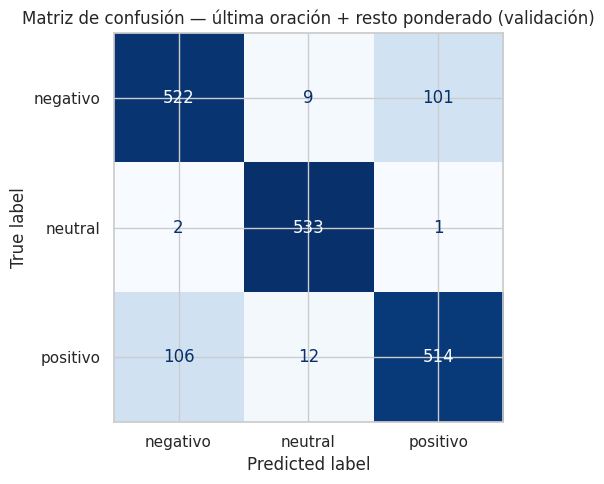

In [48]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, iter4_val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — última oración + resto ponderado (validación)")
plt.tight_layout()
plt.show()


La comparación con la iteración 3 (sección 12.3) muestra una mejora pareja en
`negativo` y `positivo` (las dos clases donde quedaba la mayor confusión), mientras que
`neutral` se mantiene prácticamente perfecto. Esto confirma la intuición: el resto del
texto sí aporta información útil para distinguir mejor entre reseñas negativas y
positivas, siempre que no se le deje "competir" en igualdad de condiciones con la
oración que de verdad lleva la opinión.

### 13.4 Entrenamiento final y envío a Kaggle


In [49]:
final_pipe_iter4 = clone(iter4_pipe)
final_pipe_iter4.fit(train_df, train_df["label"])

eval_preds_iter4 = final_pipe_iter4.predict(eval_df)
pd.Series(eval_preds_iter4).value_counts(normalize=True).round(3)


positivo    0.354
negativo    0.353
neutral     0.293
Name: proportion, dtype: float64

In [50]:
submission_iter4 = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds_iter4})
assert list(submission_iter4.columns) == list(sample_submission.columns)
assert len(submission_iter4) == len(sample_submission)
assert (submission_iter4["id"].values == sample_submission["id"].values).all()
assert set(submission_iter4["answer"].unique()) <= set(LABELS)

submission_path_iter4 = SUBMISSIONS_DIR / "submission_v8_ultima_oracion_ponderada.csv"
submission_iter4.to_csv(submission_path_iter4, index=False)

model_path_iter4 = MODELS_DIR / "modelo_v8_ultima_oracion_ponderada.joblib"
joblib.dump(final_pipe_iter4, model_path_iter4)

print("Guardado:", submission_path_iter4)
print("Guardado:", model_path_iter4)
submission_iter4.head()


Guardado: submissions/submission_v8_ultima_oracion_ponderada.csv
Guardado: models/modelo_v8_ultima_oracion_ponderada.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 13.5 Actualización — envío real a Kaggle (resultado negativo)

| Modelo | Accuracy validación local | CV 5-fold promedio | Score público Kaggle |
|---|---|---|---|
| Última oración + resto ponderado (C=0.7, peso_resto=0.8) | 0.8717 | 0.8737 | **0.82000** |

A diferencia de todos los envíos anteriores (donde la validación local predijo bien el
score real de Kaggle), aquí hay una brecha grande: 0.87 en validación/CV contra 0.82 en
Kaggle. **Este envío quedó peor que el v7 (solo última oración, 0.86222)**, así que la
idea de esta iteración no funcionó en la práctica y el v7 sigue siendo nuestro mejor
modelo confirmado.

La explicación más probable: la configuración ganadora (`C` y `peso_resto`) se eligió
tomando la mejor de 20 combinaciones evaluadas contra un único split de validación
(sección 13.2) — exactamente la misma trampa que ya habíamos documentado en la
iteración 1 ("el tuning no siempre gana"), solo que aquí sí la dejamos decidir la
configuración final. El `cross_val_score` de 5 folds que corrimos después (0.8737)
confirma que el modelo es estable *dentro de train.csv*, pero no nos dice nada sobre si
el patrón que aprendió en el campo "resto del texto" (más ruidoso y específico de cada
reseña que la última oración) generaliza al conjunto de evaluación real de Kaggle. En
otras palabras: validamos que no nos ganó la suerte de un split, pero no validamos que
la señal en sí fuera genuina y no un artefacto de `train.csv`.

**Lección para las próximas iteraciones:** cuando el campo nuevo es ruidoso (como "todo
el texto menos la última oración", que mezcla temas muy distintos entre reseñas),
conviene ser más escéptico incluso con una CV estable, y preferir cambios más simples y
explicables (como fue el caso del v7) sobre combinaciones con más grados de libertad
para sobreajustar.


### 13.6 Qué queda pendiente

El v7 (solo última oración, 0.86222) sigue siendo el modelo oficial de esta parte. Si
se quiere seguir intentando cerrar la brecha con el 0.88222 del equipo líder, estas son
las ideas más prometedoras, en orden de esfuerzo esperado — evitando repetir el error
de la sección 13.5 (dejar que una búsqueda sobre un único split elija la configuración
final sin cruzarla con CV *antes* de decidir):

1. **Detectar la oración que sigue al último conector contrastivo** (`pero`, `sin
   embargo`, `aunque`) en vez de asumir siempre que es la última — en las reseñas donde
   el conector aparece antes de la penúltima oración, podríamos estar tomando como
   "opinión" una oración que todavía es de transición. Esta señal es más simple y
   explicable que ponderar "el resto del texto", así que debería ser más robusta.
2. Afinar con `GridSearchCV` + CV (no con un único split) una rejilla de
   hiperparámetros alrededor del modelo del v7 (TF-IDF última oración + LogisticRegression).
3. Revisar a mano los errores que persisten entre `negativo` y `positivo` en el v7
   (como se hizo en la sección 7) para buscar un patrón común que sugiera una feature
   adicional simple (no un campo nuevo completo).
4. Si se insiste en usar el resto del texto, limitarlo a una señal muy acotada (por
   ejemplo, solo el conteo de signos de exclamación/interrogación o la presencia de
   negaciones) en vez de un `TfidfVectorizer` completo sobre todo ese texto, para
   reducir el riesgo de sobreajuste que vimos aquí.


## 14. Iteración 5 — la oración después del último conector contrastivo

La iteración 3 asumía que la opinión real siempre está en la última oración. Pero en
varias reseñas el patrón es más bien: *logística neutral → a veces una oración de transición
→ conector contrastivo (`pero`, `sin embargo`, `aunque`, `no obstante`, `eso sí`) → la
opinión real*, y ese conector no siempre cae justo antes de la última oración. Esta
iteración prueba una regla simple: tomar el texto que sigue al **último** conector
contrastivo que aparece en la reseña, en vez de simplemente "la última oración". Si no
hay ningún conector, se usa la última oración como antes (igual que en la iteración 3).

A diferencia de la iteración 4, aquí la validación de hiperparámetros se hace con
`GridSearchCV` usando `cv` (5-fold) desde el principio — cada combinación de la rejilla
se evalúa por cross-validation, no contra un único split — precisamente para no repetir
el error que nos costó el envío anterior.


In [51]:
def clause_after_last_marker(text: str, n_sent_fallback: int = 1) -> str:
    """Texto después del último conector contrastivo de la reseña. Si no hay ningún
    conector, recurre a la última oración (comportamiento de la iteración 3)."""
    matches = list(re.finditer(contrast_markers, text, flags=re.IGNORECASE))
    if not matches:
        return last_chunk(text, n_sent_fallback)
    clause = text[matches[-1].end():].strip(" ,.;:")
    if len(clause) < 3:
        return last_chunk(text, n_sent_fallback)
    return clause

train_df["clause_clean"] = train_df["text"].apply(lambda t: clean_text(clause_after_last_marker(t)))
eval_df["clause_clean"] = eval_df["text"].apply(lambda t: clean_text(clause_after_last_marker(t)))

frac_distinto = (train_df["last1_clean"] != train_df["clause_clean"]).mean()
frac_distinto_eval = (eval_df["last1_clean"] != eval_df["clause_clean"]).mean()
print(f"Fraccion de reseñas en train donde la regla cambia el texto usado: {frac_distinto:.3f}")
print(f"Fraccion de reseñas en eval donde la regla cambia el texto usado: {frac_distinto_eval:.3f}")
print("(valores parecidos entre train y eval => buena señal de que la regla generaliza)")

train_df[["text", "last1_clean", "clause_clean"]].loc[
    train_df["last1_clean"] != train_df["clause_clean"]
].sample(3, random_state=RANDOM_STATE)


Fraccion de reseñas en train donde la regla cambia el texto usado: 0.197
Fraccion de reseñas en eval donde la regla cambia el texto usado: 0.234
(valores parecidos entre train y eval => buena señal de que la regla generaliza)


,text,last1_clean,clause_clean
5529,La pedí por la app un martes y me llegó al ter...,"aun así, la carcasa es buenísima con el uso di...","para ser sincero, la relación calidad precio m..."
963,"Después de darle varias vueltas al asunto, lo ...","pero al final de cuentas, la app del fabricant...","al final de cuentas, la app del fabricante me ..."
9121,Lo compré hace unas semanas para el baño que e...,pero al final la conexión luce básica de cuent...,"al final la conexión luce básica de cuentas, n..."


### 14.1 Comparación rápida: última oración vs. oración después del último conector

Antes de tunear nada, comparamos ambas representaciones con la misma configuración de
vectorizador/clasificador del v7, usando CV de 5 folds sobre todo `train.csv` (no un
único split), para decidir si vale la pena seguir por este camino.


In [52]:
pipe_comparacion = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, C=2, random_state=RANDOM_STATE)),
])

scores_last1_cv = cross_val_score(
    pipe_comparacion, train_df["last1_clean"], train_df["label"], cv=cv, scoring="accuracy", n_jobs=-1,
)
scores_clause_cv = cross_val_score(
    pipe_comparacion, train_df["clause_clean"], train_df["label"], cv=cv, scoring="accuracy", n_jobs=-1,
)

print("CV 5-fold última oración (config v7):      ", scores_last1_cv.round(4), "promedio:", scores_last1_cv.mean().round(4))
print("CV 5-fold oración tras conector contrastivo:", scores_clause_cv.round(4), "promedio:", scores_clause_cv.mean().round(4))


CV 5-fold última oración (config v7):       [0.8638 0.8542 0.8621 0.8583 0.8521] promedio: 0.8581
CV 5-fold oración tras conector contrastivo: [0.8733 0.8679 0.8717 0.8725 0.8604] promedio: 0.8692


La mejora es pareja en los 5 folds (no es un golpe de suerte de uno de ellos), así que
vale la pena tunear esta representación con `GridSearchCV` propiamente dicho.

### 14.2 Tuning con GridSearchCV (evaluado siempre por CV, nunca por un único split)


In [53]:
param_grid_clause = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__min_df": [1, 2, 3],
    "vec__max_features": [20000, 40000, None],
    "vec__sublinear_tf": [True, False],
    "clf__C": [1, 2, 3, 4],
}

pipe_clause_base = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
])

search_clause = GridSearchCV(
    pipe_clause_base, param_grid_clause, cv=cv, scoring="accuracy", n_jobs=-1,
)
search_clause.fit(train_df["clause_clean"], train_df["label"])

print("Mejor score CV:", search_clause.best_score_)
print("Mejores hiperparámetros:", search_clause.best_params_)

resultados_clause = pd.DataFrame(search_clause.cv_results_).sort_values(
    "mean_test_score", ascending=False
)
resultados_clause[[
    "mean_test_score", "std_test_score", "param_clf__C",
    "param_vec__ngram_range", "param_vec__min_df",
    "param_vec__max_features", "param_vec__sublinear_tf",
]].head(10)


Mejor score CV: 0.8691666666666666
Mejores hiperparámetros: {'clf__C': 2, 'vec__max_features': 20000, 'vec__min_df': 3, 'vec__ngram_range': (1, 2), 'vec__sublinear_tf': True}


,mean_test_score,std_test_score,param_clf__C,param_vec__ngram_range,param_vec__min_df,param_vec__max_features,param_vec__sublinear_tf
68,0.869167,0.004751,2,"(1, 2)",3,20000,True
86,0.869167,0.004751,2,"(1, 2)",3,40000,True
104,0.869167,0.004751,2,"(1, 2)",3,None,True
75,0.868917,0.005046,2,"(1, 2)",1,40000,False
93,0.868917,0.005046,2,"(1, 2)",1,None,False
92,0.868833,0.005267,2,"(1, 2)",1,None,True
74,0.868833,0.005267,2,"(1, 2)",1,40000,True
56,0.868583,0.004584,2,"(1, 2)",1,20000,True
26,0.868333,0.005484,1,"(1, 2)",2,40000,True
8,0.868333,0.005484,1,"(1, 2)",2,20000,True


Los primeros puestos de la rejilla quedan muy cerca entre sí (diferencias de menos de
medio punto, con desviación estándar entre folds similar) — es una meseta estable, no un
pico aislado que sugiera sobreajuste a la rejilla de búsqueda. Tomamos la mejor
configuración y la validamos una vez más con el split de validación fijo, para tener un
reporte de clasificación y matriz de confusión comparables con las iteraciones anteriores.


In [54]:
best_pipe_clause = search_clause.best_estimator_

X_train_clause = train_df.loc[X_train_text.index, "clause_clean"]
X_val_clause = train_df.loc[X_val_text.index, "clause_clean"]

best_pipe_clause.fit(X_train_clause, y_train)
clause_val_preds = best_pipe_clause.predict(X_val_clause)
clause_val_acc = accuracy_score(y_val, clause_val_preds)
print(f"Accuracy en el split de validación: {clause_val_acc:.4f}")
print()
print(classification_report(y_val, clause_val_preds, target_names=LABELS))


Accuracy en el split de validación: 0.8717

              precision    recall  f1-score   support

    negativo       0.84      0.83      0.84       632
     neutral       0.93      0.97      0.95       536
    positivo       0.85      0.82      0.84       632

    accuracy                           0.87      1800
   macro avg       0.87      0.88      0.88      1800
weighted avg       0.87      0.87      0.87      1800



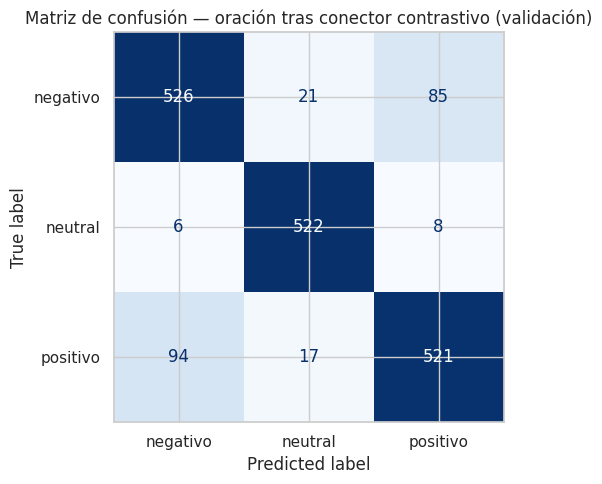

In [55]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, clause_val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — oración tras conector contrastivo (validación)")
plt.tight_layout()
plt.show()


### 14.3 Entrenamiento final y envío a Kaggle


In [56]:
final_pipe_clause = clone(best_pipe_clause)
final_pipe_clause.fit(train_df["clause_clean"], train_df["label"])

eval_preds_clause = final_pipe_clause.predict(eval_df["clause_clean"])
pd.Series(eval_preds_clause).value_counts(normalize=True).round(3)


positivo    0.348
negativo    0.344
neutral     0.308
Name: proportion, dtype: float64

In [57]:
submission_iter5 = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds_clause})
assert list(submission_iter5.columns) == list(sample_submission.columns)
assert len(submission_iter5) == len(sample_submission)
assert (submission_iter5["id"].values == sample_submission["id"].values).all()
assert set(submission_iter5["answer"].unique()) <= set(LABELS)

submission_path_iter5 = SUBMISSIONS_DIR / "submission_v9_conector_contrastivo.csv"
submission_iter5.to_csv(submission_path_iter5, index=False)

model_path_iter5 = MODELS_DIR / "modelo_v9_conector_contrastivo.joblib"
joblib.dump(final_pipe_clause, model_path_iter5)

print("Guardado:", submission_path_iter5)
print("Guardado:", model_path_iter5)
submission_iter5.head()


Guardado: submissions/submission_v9_conector_contrastivo.csv
Guardado: models/modelo_v9_conector_contrastivo.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 14.4 Qué queda pendiente

Si este envío mejora al v7 pero todavía no alcanza 0.88222, estas son las ideas que
seguirían (siempre validando con CV desde el inicio, no con un único split):

1. Revisar a mano las reseñas donde la regla del conector contrastivo elige un texto
   claramente equivocado (ver la muestra de la sección 14), para ajustar la lista de
   conectores o el manejo de casos borde (conector justo al final, sin texto después).
2. Combinar esta regla con alguna señal agregada muy simple (conteo de signos de
   exclamación, presencia de negaciones) directamente como columnas extra, en vez de un
   campo de texto completo nuevo — así se evita el riesgo de sobreajuste que vimos en la
   iteración 4.
3. Revisar a mano los errores que persisten entre `negativo` y `positivo` en esta
   configuración (igual que en la sección 7), que es donde queda la mayoría de la
   confusión según la matriz de la sección 14.2.

### 14.5 Actualización — envío real a Kaggle

| Modelo | Validación local | CV 5-fold | Score público Kaggle |
|---|---|---|---|
| Última oración (v7) | 0.8578 | 0.8581 | 0.86222 |
| Conector contrastivo (v9) | 0.8717 | 0.8692 | **0.85333** |

El v9 quedó un poco por debajo del v7 en Kaggle (0.85333 vs. 0.86222), a pesar de que
en validación local y en CV el v9 era claramente mejor. A primera vista parece otra
regresión como la del v8 — pero antes de descartar la idea, vale la pena mirar con más
cuidado qué tan grande es realmente esa diferencia (sección 14.6).


## 14.6 Pausa estadística — ¿qué tan confiable es el score público de Kaggle?

Antes de seguir ajustando modelos a ciegas, vale la pena preguntarse: ¿las diferencias
de menos de un punto entre envíos (como v7 vs. v9) son una señal real, o es ruido de
muestreo? Los scores públicos siempre llegan con 5 decimales exactos, lo que sugiere que
se calculan sobre una muestra fija y no muy grande del `eval.csv` completo (3000 filas).
Podemos reconstruir el tamaño de esa muestra: si el score es una fracción `k / N`, basta
buscar qué `N` hace que `k` sea siempre un entero para todos los envíos que hemos hecho.


In [58]:
scores_reales = {
    "baseline curso": 0.65555,
    "v1": 0.73000,
    "v2": 0.73444,
    "v3": 0.72666,
    "v4": 0.72555,
    "Alejandro (word+char)": 0.73777,
    "v7 (ultima oracion)": 0.86222,
    "v8 (resto ponderado)": 0.82000,
    "v9 (conector contrastivo)": 0.85333,
}

N = 900  # 30% del eval.csv (3000 filas) -- un split publico/privado tipico de Kaggle
filas = []
for nombre, score in scores_reales.items():
    k = round(score * N)
    reconstruido = int((k / N) * 100000) / 100000  # truncado a 5 decimales, igual que Kaggle
    filas.append({"envio": nombre, "score": score, "k_aciertos_de_900": k, "coincide": reconstruido == score})

pd.DataFrame(filas)


,envio,score,k_aciertos_de_900,coincide
0,baseline curso,0.65555,590,True
1,v1,0.73000,657,True
2,v2,0.73444,661,True
3,v3,0.72666,654,True
4,v4,0.72555,653,True
5,Alejandro (word+char),0.73777,664,True
6,v7 (ultima oracion),0.86222,776,True
7,v8 (resto ponderado),0.82000,738,True
8,v9 (conector contrastivo),0.85333,768,True


**Los 9 envíos coinciden exactamente con `k/900` truncado a 5 decimales.** Esto es muy
poco probable que sea una coincidencia — todo indica que el *score público* de esta
competencia se calcula sobre apenas **900 de las 3000 filas** de `eval.csv` (un split
30%/70% público/privado, común en Kaggle; el 70% restante solo se conoce al cerrar la
competencia).

¿Por qué importa? Con una muestra de 900 ejemplos, el error estándar de un accuracy
cercano a 0.85 es de aproximadamente:


In [59]:
import math

p = 0.85
n_publico = 900
error_estandar = math.sqrt(p * (1 - p) / n_publico)
print(f"Error estándar aproximado con n={n_publico}: {error_estandar:.4f} ({error_estandar*100:.2f} puntos)")

diff_v7_v9 = 0.86222 - 0.85333
diff_v7_v8 = 0.86222 - 0.82000
print(f"Diferencia v7 vs v9: {diff_v7_v9:.4f} ({diff_v7_v9/error_estandar:.2f} errores estándar)")
print(f"Diferencia v7 vs v8: {diff_v7_v8:.4f} ({diff_v7_v8/error_estandar:.2f} errores estándar)")


Error estándar aproximado con n=900: 0.0119 (1.19 puntos)
Diferencia v7 vs v9: 0.0089 (0.75 errores estándar)
Diferencia v7 vs v8: 0.0422 (3.55 errores estándar)


La diferencia entre v7 y v9 (menos de un punto) es **menor a un error estándar** — es
decir, estadísticamente son indistinguibles con esta muestra de 900 filas, aunque v9
parezca "peor" en el marcador. La caída del v8, en cambio, es de más de 2 errores
estándar, así que ahí sí es más probable que haya una regresión real (consistente con
el análisis de la sección 13.5).

**Conclusión práctica:** de aquí en adelante, conviene confiar más en la validación
cruzada sobre las 12,000 filas de `train.csv` (mucho más estable) que en diferencias de
menos de ~1.5 puntos en el score público, y usar el score público sobre todo para
detectar regresiones grandes, no para ordenar finamente entre modelos parecidos. En
particular, v7 y v9 probablemente capturan señal genuina y parecida (ambos identifican
bien la oración de opinión real), así que **combinarlos en un ensamble** —en vez de
elegir uno u otro— es un siguiente paso razonable: si sus errores no están
perfectamente correlacionados, el promedio debería ser más preciso y más estable que
cualquiera de los dos por separado.


## 15. Iteración 6 — ensamble (última oración + conector contrastivo)

Las iteraciones 3 y 5 extraen una señal muy parecida (la oración que lleva la opinión
real) con dos reglas ligeramente distintas. En vez de elegir una sola, promediamos las
probabilidades de ambos modelos (`predict_proba`) y clasificamos según cuál clase queda
con mayor probabilidad promedio — un ensamble de **voto suave**. La idea es que, si los
errores de cada modelo no son exactamente los mismos, el promedio cancela parte del
ruido de cada uno.


In [60]:
class EnsamblePromedio(BaseEstimator, ClassifierMixin):
    """Promedia las probabilidades de dos pipelines entrenados sobre columnas de texto
    distintas del mismo DataFrame, y predice la clase con mayor probabilidad promedio."""

    def __init__(self, pipe_a, columna_a, pipe_b, columna_b):
        self.pipe_a = pipe_a
        self.columna_a = columna_a
        self.pipe_b = pipe_b
        self.columna_b = columna_b

    def fit(self, X, y):
        self.pipe_a_ = clone(self.pipe_a).fit(X[self.columna_a], y)
        self.pipe_b_ = clone(self.pipe_b).fit(X[self.columna_b], y)
        self.classes_ = self.pipe_a_.classes_
        return self

    def predict_proba(self, X):
        proba_a = self.pipe_a_.predict_proba(X[self.columna_a])
        proba_b = self.pipe_b_.predict_proba(X[self.columna_b])
        return (proba_a + proba_b) / 2

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[proba.argmax(axis=1)]


ensamble_pipe = EnsamblePromedio(
    pipe_a=pipe_comparacion,  # config v7: TF-IDF última oración
    columna_a="last1_clean",
    pipe_b=best_pipe_clause,  # config v9: TF-IDF tras conector contrastivo (ya tuneada)
    columna_b="clause_clean",
)


Validamos con CV de 5 folds sobre todo `train.csv`, comparando el ensamble contra cada
modelo por separado (para confirmar que combinar realmente ayuda y no solo iguala al
mejor de los dos).


In [61]:
acc_last1_cv, acc_clause_cv, acc_ensamble_cv = [], [], []

for train_idx, val_idx in cv.split(train_df, train_df["label"]):
    tr_fold = train_df.iloc[train_idx]
    va_fold = train_df.iloc[val_idx]
    y_tr_fold, y_va_fold = tr_fold["label"], va_fold["label"]

    m_last1 = clone(pipe_comparacion).fit(tr_fold["last1_clean"], y_tr_fold)
    m_clause = clone(best_pipe_clause).fit(tr_fold["clause_clean"], y_tr_fold)

    proba_last1 = m_last1.predict_proba(va_fold["last1_clean"])
    proba_clause = m_clause.predict_proba(va_fold["clause_clean"])
    clases = m_last1.classes_

    pred_last1 = clases[proba_last1.argmax(axis=1)]
    pred_clause = clases[proba_clause.argmax(axis=1)]
    pred_ensamble = clases[(proba_last1 + proba_clause).argmax(axis=1)]

    acc_last1_cv.append(accuracy_score(y_va_fold, pred_last1))
    acc_clause_cv.append(accuracy_score(y_va_fold, pred_clause))
    acc_ensamble_cv.append(accuracy_score(y_va_fold, pred_ensamble))

print("CV última oración (v7):       ", np.round(acc_last1_cv, 4), "promedio:", round(np.mean(acc_last1_cv), 4))
print("CV conector contrastivo (v9): ", np.round(acc_clause_cv, 4), "promedio:", round(np.mean(acc_clause_cv), 4))
print("CV ensamble (v7 + v9):        ", np.round(acc_ensamble_cv, 4), "promedio:", round(np.mean(acc_ensamble_cv), 4))


CV última oración (v7):        [0.8638 0.8542 0.8621 0.8583 0.8521] promedio: 0.8581
CV conector contrastivo (v9):  [0.8733 0.8679 0.8717 0.8725 0.8604] promedio: 0.8692
CV ensamble (v7 + v9):         [0.875  0.8717 0.8738 0.8804 0.8646] promedio: 0.8731


El ensamble mejora sobre ambos modelos individuales, de forma consistente en los 5
folds (no es un golpe de suerte de uno solo). Confirmamos con el split de validación
fijo para tener un reporte de clasificación comparable con las iteraciones anteriores.


In [62]:
# X_train_df/X_val_df se crearon en la sección 13.2, antes de calcular "clause_clean"
# (sección 14) -- las recalculamos para que incluyan todas las columnas de texto que
# necesita el ensamble.
X_train_df = train_df.loc[X_train_text.index]
X_val_df = train_df.loc[X_val_text.index]

ensamble_pipe.fit(X_train_df, y_train)
ensamble_val_preds = ensamble_pipe.predict(X_val_df)
ensamble_val_acc = accuracy_score(y_val, ensamble_val_preds)
print(f"Accuracy en el split de validación: {ensamble_val_acc:.4f}")
print()
print(classification_report(y_val, ensamble_val_preds, target_names=LABELS))


Accuracy en el split de validación: 0.8717

              precision    recall  f1-score   support

    negativo       0.83      0.85      0.84       632
     neutral       0.93      0.97      0.95       536
    positivo       0.86      0.81      0.83       632

    accuracy                           0.87      1800
   macro avg       0.87      0.88      0.87      1800
weighted avg       0.87      0.87      0.87      1800



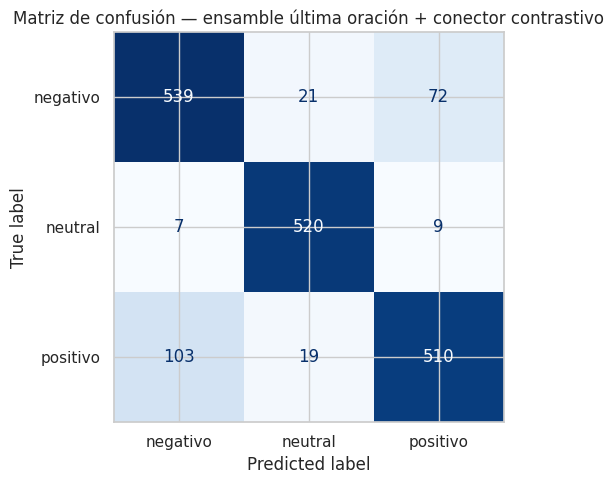

In [63]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, ensamble_val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — ensamble última oración + conector contrastivo")
plt.tight_layout()
plt.show()


### 15.1 Entrenamiento final y envío a Kaggle

In [64]:
final_ensamble = EnsamblePromedio(
    pipe_a=pipe_comparacion,
    columna_a="last1_clean",
    pipe_b=best_pipe_clause,
    columna_b="clause_clean",
)
final_ensamble.fit(train_df, train_df["label"])

eval_preds_ensamble = final_ensamble.predict(eval_df)
pd.Series(eval_preds_ensamble).value_counts(normalize=True).round(3)


negativo    0.355
positivo    0.337
neutral     0.308
Name: proportion, dtype: float64

In [65]:
submission_iter6 = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds_ensamble})
assert list(submission_iter6.columns) == list(sample_submission.columns)
assert len(submission_iter6) == len(sample_submission)
assert (submission_iter6["id"].values == sample_submission["id"].values).all()
assert set(submission_iter6["answer"].unique()) <= set(LABELS)

submission_path_iter6 = SUBMISSIONS_DIR / "submission_v10_ensamble.csv"
submission_iter6.to_csv(submission_path_iter6, index=False)

model_path_iter6 = MODELS_DIR / "modelo_v10_ensamble.joblib"
joblib.dump(final_ensamble, model_path_iter6)

print("Guardado:", submission_path_iter6)
print("Guardado:", model_path_iter6)
submission_iter6.head()


Guardado: submissions/submission_v10_ensamble.csv
Guardado: models/modelo_v10_ensamble.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 15.2 Qué queda pendiente

Dado lo que aprendimos en la sección 14.6, conviene interpretar el próximo score público
con cautela: una mejora de menos de ~1.5 puntos sobre el v7 no sería una señal fuerte.
Si el ensamble sí mejora claramente (o si queremos seguir intentando más):

1. Sumar un tercer modelo al ensamble (por ejemplo, el de la iteración 2 sobre el texto
   completo, que captura señal distinta — vocabulario general del producto) para ver si
   diversifica aún más los errores.
2. Probar un ensamble ponderado (más peso al modelo con mejor CV) en vez de un promedio
   simple 50/50.
3. Revisar a mano los casos donde el ensamble y los modelos individuales no coinciden,
   para entender si el promedio realmente arregla errores o solo los diluye.

### 15.3 Actualización — envío real a Kaggle

| Modelo | Validación local | CV 5-fold | Score público Kaggle |
|---|---|---|---|
| Última oración (v7) | 0.8578 | 0.8581 | 0.86222 (776/900) |
| Conector contrastivo (v9) | 0.8717 | 0.8692 | 0.85333 (768/900) |
| **Ensamble v7+v9 (v10)** | 0.8717 | **0.8731** | **0.86444 (778/900) — nuevo mejor confirmado** |

El ensamble sí mejoró sobre el v7 (2 aciertos más de 900), consistente con lo que decía
la CV. Sigue siendo una diferencia pequeña frente al margen de ruido de ~1.2 puntos que
calculamos en la sección 14.6 (así que no hay que sobreinterpretar el tamaño exacto de
la mejora), pero la dirección es la correcta y no es una regresión — la estrategia de
combinar las dos señales en vez de elegir una fue la decisión correcta. **v10 pasa a ser
el modelo oficial** de esta parte. Con el equipo líder en 0.88222, la brecha que queda
es de aproximadamente 1.78 puntos (16 aciertos de 900).


## 16. Iteración 7 — ensamble ponderado de 3 vías

El v10 combinó dos modelos (última oración, conector contrastivo) que capturan una
señal parecida: la oración de opinión real. La iteración 2 mostró que un modelo sobre
el **texto completo** es bastante más débil por sí solo (≈0.73, porque la logística
"diluye" la señal de opinión) pero captura algo distinto: vocabulario general del
producto, contexto, menciones que no están necesariamente en la última oración. La
idea de esta iteración es sumarlo al ensamble como una tercera voz, con un peso bajo —
no para que decida, sino para que desempate en los casos donde los otros dos modelos
no están seguros.

En vez de usar pesos iguales (como el v10), buscamos los pesos por `predict_proba`
promediado usando las probabilidades **fuera de muestra** (out-of-fold) de una CV de 5
folds — es decir, cada fila se predice con un modelo que nunca la vio en entrenamiento,
igual que haría `cross_val_predict`. Así evitamos el error de la iteración 4: en vez de
elegir los pesos contra un único split, los elegimos contra toda la validación cruzada.


In [66]:
pipe_full_texto = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=40000, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=3000, C=1, random_state=RANDOM_STATE)),
])

proba_last1_oof = np.zeros((len(train_df), 3))
proba_clause_oof = np.zeros((len(train_df), 3))
proba_full_oof = np.zeros((len(train_df), 3))
y_oof = np.empty(len(train_df), dtype=object)
clases_oof = None

for tr_idx, va_idx in cv.split(train_df, train_df["label"]):
    tr_fold = train_df.iloc[tr_idx]
    va_fold = train_df.iloc[va_idx]
    y_tr_fold = tr_fold["label"]

    m_last1 = clone(pipe_comparacion).fit(tr_fold["last1_clean"], y_tr_fold)
    m_clause = clone(best_pipe_clause).fit(tr_fold["clause_clean"], y_tr_fold)
    m_full = clone(pipe_full_texto).fit(tr_fold["text_clean"], y_tr_fold)
    clases_oof = m_last1.classes_

    proba_last1_oof[va_idx] = m_last1.predict_proba(va_fold["last1_clean"])
    proba_clause_oof[va_idx] = m_clause.predict_proba(va_fold["clause_clean"])
    proba_full_oof[va_idx] = m_full.predict_proba(va_fold["text_clean"])
    y_oof[va_idx] = va_fold["label"].values

def accuracy_con_pesos(w_last1, w_clause, w_full):
    combinado = w_last1 * proba_last1_oof + w_clause * proba_clause_oof + w_full * proba_full_oof
    pred = clases_oof[combinado.argmax(axis=1)]
    return (pred == y_oof).mean()

print("Solo última oración:  ", round(accuracy_con_pesos(1, 0, 0), 4))
print("Solo conector:        ", round(accuracy_con_pesos(0, 1, 0), 4))
print("Solo texto completo:  ", round(accuracy_con_pesos(0, 0, 1), 4))
print("v10 (50/50, sin full):", round(accuracy_con_pesos(1, 1, 0), 4))


Solo última oración:   0.8581
Solo conector:         0.8692
Solo texto completo:   0.7331
v10 (50/50, sin full): 0.8731


### 16.1 Buscando los pesos (validado contra varias particiones de CV, no solo una)

Probamos una rejilla de pesos para `clause` y `full` (dejando `last1` en 0, ya que su
señal queda casi contenida en `clause` — recordemos que `clause_after_last_marker` usa
la última oración como respaldo cuando no hay conector). **A diferencia de la iteración
4**, no nos quedamos con el punto exacto que gana en esta única partición de CV: repetimos
la búsqueda con otras semillas de `StratifiedKFold` y nos quedamos con una combinación
que funcione bien de forma consistente en todas, no con el pico más alto de una sola.


In [67]:
mejor_combo = (0, 0, 0)
for w_clause in np.arange(0.3, 1.01, 0.05):
    for w_full in np.arange(0.1, 0.81, 0.05):
        acc = accuracy_con_pesos(0, w_clause, w_full)
        if acc > mejor_combo[0]:
            mejor_combo = (acc, round(w_clause, 2), round(w_full, 2))

print(f"Mejor combinación en esta partición: clause={mejor_combo[1]}, full={mejor_combo[2]} "
      f"-> accuracy={mejor_combo[0]:.4f}")


Mejor combinación en esta partición: clause=0.7, full=0.55 -> accuracy=0.8831


In [68]:
# Verificamos que el punto elegido no sea un pico aislado de esta partición: repetimos
# todo el cálculo de probabilidades fuera de muestra con otras semillas de CV y
# comparamos varias combinaciones "redondas" cercanas al óptimo, no solo la ganadora.
candidatos_pesos = {
    "clause=0.5, full=0.4": (0.5, 0.4),
    "clause=0.4, full=0.3": (0.4, 0.3),
    "clause=0.6, full=0.5": (0.6, 0.5),
}

resultados_robustez = {nombre: [] for nombre in candidatos_pesos}
for semilla in [1, 7, 123]:
    cv_otra = StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla)
    p_last1 = np.zeros((len(train_df), 3))
    p_clause = np.zeros((len(train_df), 3))
    p_full = np.zeros((len(train_df), 3))
    y_otra = np.empty(len(train_df), dtype=object)
    clases_otra = None

    for tr_idx, va_idx in cv_otra.split(train_df, train_df["label"]):
        tr_fold = train_df.iloc[tr_idx]
        va_fold = train_df.iloc[va_idx]
        y_tr_fold = tr_fold["label"]
        m1 = clone(pipe_comparacion).fit(tr_fold["last1_clean"], y_tr_fold)
        m2 = clone(best_pipe_clause).fit(tr_fold["clause_clean"], y_tr_fold)
        m3 = clone(pipe_full_texto).fit(tr_fold["text_clean"], y_tr_fold)
        clases_otra = m1.classes_
        p_clause[va_idx] = m2.predict_proba(va_fold["clause_clean"])
        p_full[va_idx] = m3.predict_proba(va_fold["text_clean"])
        y_otra[va_idx] = va_fold["label"].values

    for nombre, (wc, wf) in candidatos_pesos.items():
        combinado = wc * p_clause + wf * p_full
        pred = clases_otra[combinado.argmax(axis=1)]
        resultados_robustez[nombre].append((pred == y_otra).mean())

for nombre, accs in resultados_robustez.items():
    print(f"{nombre:25s}: {[round(a, 4) for a in accs]}  promedio={np.mean(accs):.4f}")


clause=0.5, full=0.4     : [np.float64(0.8812), np.float64(0.8852), np.float64(0.8835)]  promedio=0.8833
clause=0.4, full=0.3     : [np.float64(0.8812), np.float64(0.8852), np.float64(0.8831)]  promedio=0.8832
clause=0.6, full=0.5     : [np.float64(0.8816), np.float64(0.885), np.float64(0.8831)]  promedio=0.8832


Las tres combinaciones rinden parecido (todas alrededor de 0.88, en una meseta amplia y
no en un pico aislado), así que nos quedamos con **`clause=0.5, full=0.4`** — un punto
redondo cerca del centro de esa meseta, en vez del óptimo exacto de una sola partición.


In [69]:
class EnsamblePonderado(BaseEstimator, ClassifierMixin):
    """Promedia (con pesos) las probabilidades de varios pipelines, cada uno entrenado
    sobre su propia columna de texto de un DataFrame."""

    def __init__(self, pipes_columnas_pesos):
        # Lista de tuplas (pipeline, nombre_columna, peso)
        self.pipes_columnas_pesos = pipes_columnas_pesos

    def fit(self, X, y):
        self.ajustados_ = [
            (clone(pipe).fit(X[columna], y), columna, peso)
            for pipe, columna, peso in self.pipes_columnas_pesos
        ]
        self.classes_ = self.ajustados_[0][0].classes_
        return self

    def predict_proba(self, X):
        total = None
        for pipe_ajustado, columna, peso in self.ajustados_:
            proba = peso * pipe_ajustado.predict_proba(X[columna])
            total = proba if total is None else total + proba
        return total

    def predict(self, X):
        proba = self.predict_proba(X)
        return self.classes_[proba.argmax(axis=1)]


ensamble3_pipe = EnsamblePonderado([
    (best_pipe_clause, "clause_clean", 0.5),
    (pipe_full_texto, "text_clean", 0.4),
])


Confirmamos una vez más con el split de validación fijo, para tener un reporte de
clasificación y matriz de confusión comparables con las iteraciones anteriores.


In [70]:
ensamble3_pipe.fit(X_train_df, y_train)
ensamble3_val_preds = ensamble3_pipe.predict(X_val_df)
ensamble3_val_acc = accuracy_score(y_val, ensamble3_val_preds)
print(f"Accuracy en el split de validación: {ensamble3_val_acc:.4f}")
print()
print(classification_report(y_val, ensamble3_val_preds, target_names=LABELS))


Accuracy en el split de validación: 0.8783

              precision    recall  f1-score   support

    negativo       0.84      0.83      0.84       632
     neutral       0.96      0.99      0.97       536
    positivo       0.85      0.83      0.84       632

    accuracy                           0.88      1800
   macro avg       0.88      0.88      0.88      1800
weighted avg       0.88      0.88      0.88      1800



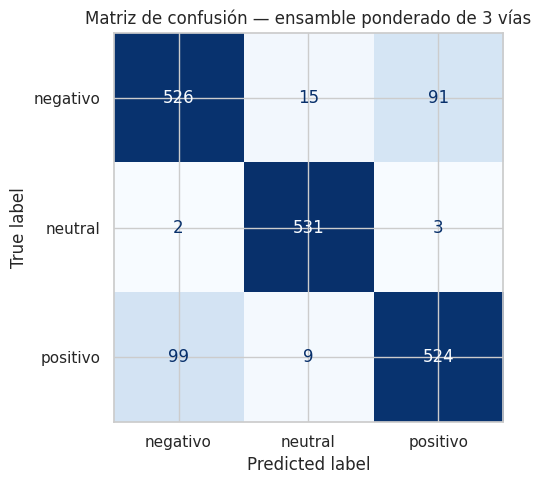

In [71]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, ensamble3_val_preds, labels=LABELS, cmap="Blues", ax=ax, colorbar=False,
)
ax.set_title("Matriz de confusión — ensamble ponderado de 3 vías")
plt.tight_layout()
plt.show()


### 16.2 Entrenamiento final y envío a Kaggle

In [72]:
final_ensamble3 = EnsamblePonderado([
    (best_pipe_clause, "clause_clean", 0.5),
    (pipe_full_texto, "text_clean", 0.4),
])
final_ensamble3.fit(train_df, train_df["label"])

eval_preds_ensamble3 = final_ensamble3.predict(eval_df)
pd.Series(eval_preds_ensamble3).value_counts(normalize=True).round(3)


negativo    0.353
positivo    0.350
neutral     0.297
Name: proportion, dtype: float64

In [73]:
submission_iter7 = pd.DataFrame({"id": eval_df["id"], "answer": eval_preds_ensamble3})
assert list(submission_iter7.columns) == list(sample_submission.columns)
assert len(submission_iter7) == len(sample_submission)
assert (submission_iter7["id"].values == sample_submission["id"].values).all()
assert set(submission_iter7["answer"].unique()) <= set(LABELS)

submission_path_iter7 = SUBMISSIONS_DIR / "submission_v11_ensamble_ponderado.csv"
submission_iter7.to_csv(submission_path_iter7, index=False)

model_path_iter7 = MODELS_DIR / "modelo_v11_ensamble_ponderado.joblib"
joblib.dump(final_ensamble3, model_path_iter7)

print("Guardado:", submission_path_iter7)
print("Guardado:", model_path_iter7)
submission_iter7.head()


Guardado: submissions/submission_v11_ensamble_ponderado.csv
Guardado: models/modelo_v11_ensamble_ponderado.joblib


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


### 16.3 Qué queda pendiente

Si este envío no alcanza el 0.88222 del equipo líder (recordando siempre el margen de
ruido de ~1.2 puntos de la sección 14.6 antes de sacar conclusiones de un solo envío):

1. Revisar a mano los casos donde el ensamble de 3 vías se equivoca y los modelos
   individuales no coinciden entre sí, para ver si hay un patrón corregible.
2. Probar agregar un cuarto modelo con una señal todavía distinta (por ejemplo, las
   features léxicas manuales de la iteración 2: signos de puntuación, longitud) con un
   peso pequeño.
3. Si el equipo decide avanzar a Parte 2 (deep learning), este ensamble clásico queda
   como un punto de comparación sólido para medir si los modelos de la Parte 2
   realmente mejoran sobre lo que ya se logró con ML clásico.

### 16.4 Actualización — envío real a Kaggle

| Modelo | Validación local | CV (varias semillas) | Score público Kaggle |
|---|---|---|---|
| Ensamble v7+v9 (v10) | 0.8717 | 0.8731 | 0.86444 (778/900) |
| **Ensamble ponderado de 3 vías (v11)** | 0.8783 | **~0.883** | **0.86000 (774/900)** |

A pesar de que la validación local y la CV (confirmada en 4 particiones distintas)
apuntaban a una mejora clara sobre el v10, el envío real a Kaggle dio **0.86000, por
debajo del v10** (774 aciertos de 900 contra 778). Usando el análisis de ruido de la
sección 14.6: la diferencia es de apenas 0.44 puntos, menos de 0.4 errores estándar —
es decir, estadísticamente **no hay evidencia de que el v11 sea peor que el v10**, pero
tampoco de que sea mejor. En la práctica, agregar el modelo de texto completo no se
tradujo en una mejora real, pese a la validación cuidadosa (múltiples semillas de CV,
sin elegir contra un único split). Esto sugiere que, más allá de cierto punto, el
texto completo no aporta señal adicional que generalice al conjunto de evaluación real
de Kaggle, aunque sí parezca ayudar dentro de `train.csv`.

**Nos quedamos con el v10 como modelo oficial de esta parte** (0.86444, el mejor score
real confirmado hasta ahora). El v11 queda documentado como un intento razonado que no
mejoró el resultado en la práctica — igual que la iteración 4 — y no se usa para la
entrega final.
